# EDA House rent

## Paso 1: Importar Liberias

In [1]:
import pandas  as pd
import numpy as np
import kagglehub
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import os

C:\Users\guill\Documents\GitHub\taller-house-rent\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Paso 2: Descargar los datos

In [2]:
path = kagglehub.dataset_download("rkb0023/houserentpredictiondataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\guill\.cache\kagglehub\datasets\rkb0023\houserentpredictiondataset\versions\1


In [3]:
files_in_directory = os.listdir(path)
print("Files in dataset directory:", files_in_directory)

Files in dataset directory: ['houseRent']


In [4]:
files_in_directory = os.listdir(f"{path}/houseRent")
print("Files in dataset directory:", files_in_directory)

Files in dataset directory: ['housePricing.docx', 'housing_train.csv']


In [5]:
df = pd.read_csv(f"{path}/houseRent/housing_train.csv")

In [6]:
df.shape

(265190, 22)

In [7]:
df.head()

,id,url,region,region_url,price,type,sqfeet,beds,baths,cats_allowed,...,wheelchair_access,electric_vehicle_charge,comes_furnished,laundry_options,parking_options,image_url,description,lat,long,state
0,7039061606,https://bham.craigslist.org/apa/d/birmingham-h...,birmingham,https://bham.craigslist.org,1195,apartment,1908,3,2.0,1,...,0,0,0,laundry on site,street parking,https://images.craigslist.org/00L0L_80pNkyDeG0...,Apartments In Birmingham AL Welcome to 100 Inv...,33.4226,-86.7065,al
1,7041970863,https://bham.craigslist.org/apa/d/birmingham-w...,birmingham,https://bham.craigslist.org,1120,apartment,1319,3,2.0,1,...,0,0,0,laundry on site,off-street parking,https://images.craigslist.org/00707_uRrY9CsNMC...,Find Your Way to Haven Apartment Homes Come ho...,33.3755,-86.8045,al
2,7041966914,https://bham.craigslist.org/apa/d/birmingham-g...,birmingham,https://bham.craigslist.org,825,apartment,1133,1,1.5,1,...,0,0,0,laundry on site,street parking,https://images.craigslist.org/00h0h_b7Bdj1NLBi...,Apartments In Birmingham AL Welcome to 100 Inv...,33.4226,-86.7065,al
3,7041966936,https://bham.craigslist.org/apa/d/birmingham-f...,birmingham,https://bham.craigslist.org,800,apartment,927,1,1.0,1,...,0,0,0,laundry on site,street parking,https://images.craigslist.org/00808_6ghZ8tSRQs...,Apartments In Birmingham AL Welcome to 100 Inv...,33.4226,-86.7065,al
4,7041966888,https://bham.craigslist.org/apa/d/birmingham-2...,birmingham,https://bham.craigslist.org,785,apartment,1047,2,1.0,1,...,0,0,0,laundry on site,street parking,https://images.craigslist.org/00y0y_21c0FOvUXm...,Apartments In Birmingham AL Welcome to 100 Inv...,33.4226,-86.7065,al


In [8]:
df.tail()

,id,url,region,region_url,price,type,sqfeet,beds,baths,cats_allowed,...,wheelchair_access,electric_vehicle_charge,comes_furnished,laundry_options,parking_options,image_url,description,lat,long,state
265185,7050851033,https://columbus.craigslist.org/apa/d/columbus...,columbus,https://columbus.craigslist.org,0,apartment,1061,2,2.0,1,...,0,0,0,w/d in unit,detached garage,https://images.craigslist.org/00m0m_8wP9hX96TZ...,â BERKLEY HOUSE â Voted #1 BEST Communit...,40.0495,-83.0669,oh
265186,7050887997,https://columbus.craigslist.org/apa/d/grove-ci...,columbus,https://columbus.craigslist.org,1069,apartment,1020,2,1.5,1,...,0,0,0,w/d hookups,detached garage,https://images.craigslist.org/00N0N_ioCvFNCv24...,!!!!Tour today and receive $5 Starbucks gift c...,39.8408,-83.0804,oh
265187,7044801015,https://columbus.craigslist.org/apa/d/columbus...,columbus,https://columbus.craigslist.org,1507,apartment,1660,2,1.5,1,...,0,0,0,NaN,NaN,https://images.craigslist.org/00j0j_5EIRWzdHCV...,"The Commons at Olentangy4765 Blairfield Dr, Co...",40.0564,-83.0417,oh
265188,7050885800,https://columbus.craigslist.org/apa/d/newark-l...,columbus,https://columbus.craigslist.org,1001,apartment,1220,3,1.5,1,...,0,0,0,w/d hookups,off-street parking,https://images.craigslist.org/00J0J_6VSTqFJb86...,www.McMillenWoods.com www.mcmillenwoods.com ...,40.0451,-82.4564,oh
265189,7050884586,https://columbus.craigslist.org/apa/d/columbus...,columbus,https://columbus.craigslist.org,1164,townhouse,1300,2,2.5,1,...,0,0,0,w/d hookups,attached garage,https://images.craigslist.org/00w0w_h1L3gxb8rG...,Park Club apartments is offering some of the B...,NaN,NaN,NaN


## Paso 3: Análisis de datos

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265190 entries, 0 to 265189
Data columns (total 22 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       265190 non-null  int64  
 1   url                      265190 non-null  object 
 2   region                   265190 non-null  object 
 3   region_url               265190 non-null  object 
 4   price                    265190 non-null  int64  
 5   type                     265190 non-null  object 
 6   sqfeet                   265190 non-null  int64  
 7   beds                     265190 non-null  int64  
 8   baths                    265190 non-null  float64
 9   cats_allowed             265190 non-null  int64  
 10  dogs_allowed             265190 non-null  int64  
 11  smoking_allowed          265190 non-null  int64  
 12  wheelchair_access        265190 non-null  int64  
 13  electric_vehicle_charge  265190 non-null  int64  
 14  come

In [10]:
df.dtypes

id                           int64
url                         object
region                      object
region_url                  object
price                        int64
type                        object
sqfeet                       int64
beds                         int64
baths                      float64
cats_allowed                 int64
dogs_allowed                 int64
smoking_allowed              int64
wheelchair_access            int64
electric_vehicle_charge      int64
comes_furnished              int64
laundry_options             object
parking_options             object
image_url                   object
description                 object
lat                        float64
long                       float64
state                       object
dtype: object

## Paso 4: Gestión de duplicaciones y valores faltantes

### 4.1 Manejo de duplicaciones

In [11]:
duplicates = df.duplicated().sum()

In [12]:
print(f"Número de registros duplicados: {duplicates}")

Número de registros duplicados: 0


### 4.2 Manejo de valores faltantes

In [13]:
len(df)

265190

In [14]:
missing_data = df.isnull().sum()[df.isnull().sum() > 0]

In [15]:
missing_data

laundry_options    54311
parking_options    95135
description            2
lat                 1419
long                1419
state                  1
dtype: int64

In [16]:
#Listar las variables con valores nulos
vars_null = [var for var in df.columns if df[var].isnull().sum() > 0]
print(len(vars_null))
#ordenar las variables con faltantes según su proporcion
df[vars_null].isnull().mean().sort_values(ascending=False)

6


parking_options    0.358743
laundry_options    0.204800
lat                0.005351
long               0.005351
description        0.000008
state              0.000004
dtype: float64

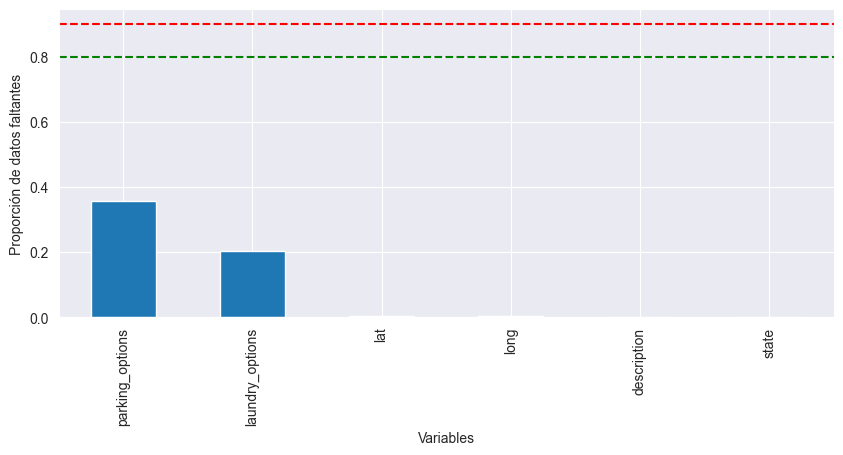

In [17]:
df[vars_null].isnull().mean().sort_values(ascending=False).plot.bar(figsize=(10,4))
plt.ylabel('Proporción de datos faltantes')
plt.xlabel('Variables')
plt.axhline(y=0.90, color='r', linestyle='--')
plt.axhline(y=0.80, color='g', linestyle='--')
plt.show()

In [18]:
df['state'].value_counts()

state
ca    33085
fl    31929
nc    18628
mi    14529
ga    13841
co    11308
ny     9991
il     9706
ks     7910
ia     7488
mn     7468
md     7451
la     7304
az     6752
oh     6558
in     6416
al     6198
nj     5711
ky     5419
ms     4973
ma     4926
id     4466
ct     3765
nd     3428
ar     3149
nm     2917
nv     2846
ne     2697
dc     2502
ak     2169
mo     2158
de     2048
hi     1840
nh     1761
mt     1339
me      420
ok       49
or       44
Name: count, dtype: int64

In [19]:
freq_encoding = df['state'].value_counts().idxmax()
df['state'].fillna(freq_encoding, inplace=True)

C:\Users\guill\AppData\Local\Temp\ipykernel_46900\1321309039.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['state'].fillna(freq_encoding, inplace=True)


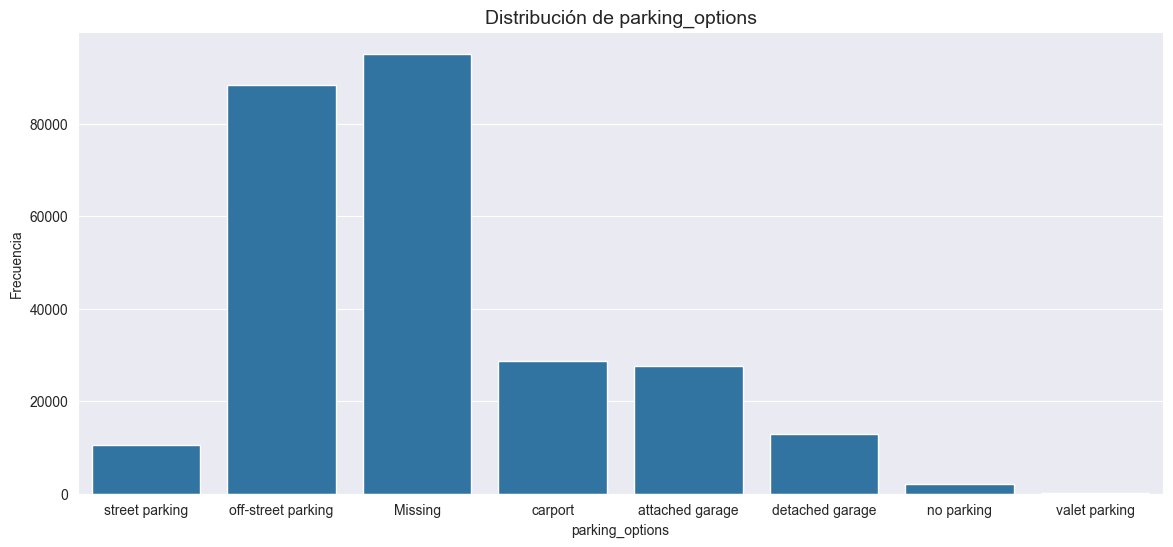

In [20]:
df_missing = df.assign(parking_options=df["parking_options"].fillna("Missing"))
plt.figure(figsize=(14, 6))
sns.countplot(data=df_missing, x="parking_options")
plt.title('Distribución de parking_options', fontsize=14)
plt.xlabel("parking_options")
plt.ylabel('Frecuencia')
plt.show()

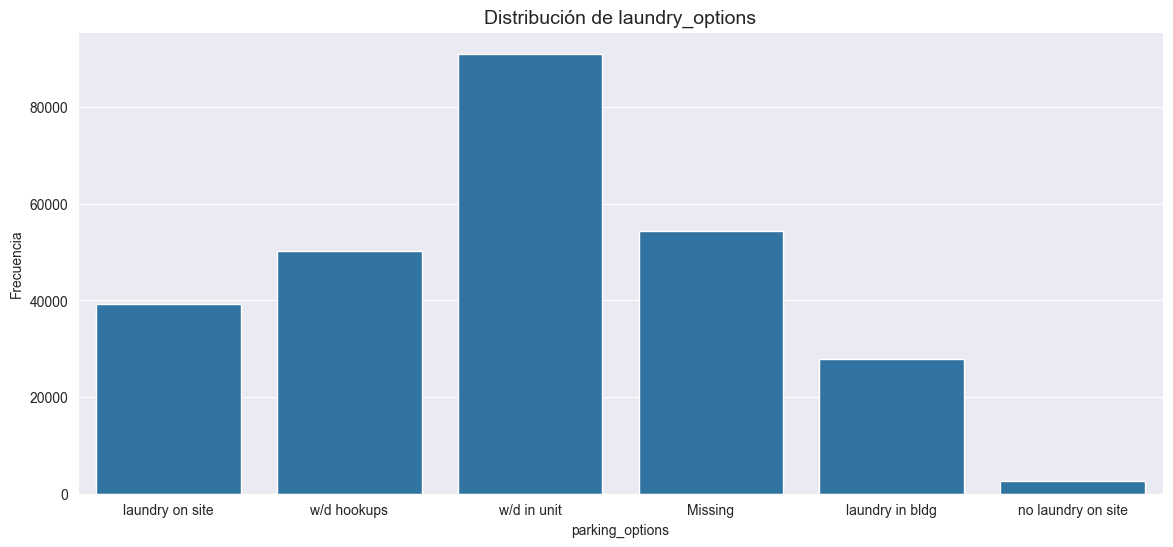

In [21]:
df_missing = df.assign(laundry_options=df["laundry_options"].fillna("Missing"))
plt.figure(figsize=(14, 6))
sns.countplot(data=df_missing, x="laundry_options")
plt.title('Distribución de laundry_options', fontsize=14)
plt.xlabel("parking_options")
plt.ylabel('Frecuencia')
plt.show()

## Paso 5:  Reducción de Datos

In [22]:
## Check "parking_options", "laundry_options"
data = df.drop(columns=["id", "url", "region_url", "image_url", "description", "lat", "long", "parking_options", "laundry_options"])


## Paso 6: Ingeniería de Características (Feature Engineering)

In [23]:
data.head()

,region,price,type,sqfeet,beds,baths,cats_allowed,dogs_allowed,smoking_allowed,wheelchair_access,electric_vehicle_charge,comes_furnished,state
0,birmingham,1195,apartment,1908,3,2.0,1,1,1,0,0,0,al
1,birmingham,1120,apartment,1319,3,2.0,1,1,1,0,0,0,al
2,birmingham,825,apartment,1133,1,1.5,1,1,1,0,0,0,al
3,birmingham,800,apartment,927,1,1.0,1,1,1,0,0,0,al
4,birmingham,785,apartment,1047,2,1.0,1,1,1,0,0,0,al


### Paso 6.1: Crear Caracteristica

In [24]:
data["price_per_sqfeet"] = data["price"] / data["sqfeet"]
data["baths_per_beds"] = data["baths"] / data["beds"]
data["beds_per_sqfeet"] = data["beds"] / data["sqfeet"]

In [25]:
data.head()

,region,price,type,sqfeet,beds,baths,cats_allowed,dogs_allowed,smoking_allowed,wheelchair_access,electric_vehicle_charge,comes_furnished,state,price_per_sqfeet,baths_per_beds,beds_per_sqfeet
0,birmingham,1195,apartment,1908,3,2.0,1,1,1,0,0,0,al,0.626310,0.666667,0.001572
1,birmingham,1120,apartment,1319,3,2.0,1,1,1,0,0,0,al,0.849128,0.666667,0.002274
2,birmingham,825,apartment,1133,1,1.5,1,1,1,0,0,0,al,0.728155,1.500000,0.000883
3,birmingham,800,apartment,927,1,1.0,1,1,1,0,0,0,al,0.862999,1.000000,0.001079
4,birmingham,785,apartment,1047,2,1.0,1,1,1,0,0,0,al,0.749761,0.500000,0.001910


## Paso 7: Agrupar las variables según el tipo

### Paso 7.1: Guardar la variable objetivo

In [26]:
targer_var = "price"

### Paso 7.2: Guardar las variables categorias

In [27]:
vars_cat = [var for var in data.columns if data[var].dtype == "O"
            or var == "cats_allowed"
            or var == "dogs_allowed"
            or var == "smoking_allowed"
            or var == "wheelchair_access"
            or var == "electric_vehicle_charge"
            or var == "comes_furnished"]

In [28]:
vars_cat

['region',
 'type',
 'cats_allowed',
 'dogs_allowed',
 'smoking_allowed',
 'wheelchair_access',
 'electric_vehicle_charge',
 'comes_furnished',
 'state']

### Paso 7.3 Guardar las variables númericas

In [29]:
vars_nums = [var for var in data.columns if data[var].dtype != "O" and var != "price" and var not in vars_cat]

In [30]:
vars_nums

['sqfeet',
 'beds',
 'baths',
 'price_per_sqfeet',
 'baths_per_beds',
 'beds_per_sqfeet']

### Paso 7.4 Variables discretas

In [31]:
vars_disc = ["beds", "baths"]

In [32]:
vars_con = ["sqfeet","price_per_sqfeet", "baths_per_beds", "beds_per_sqfeet"]

## Paso 8: Análisis Univariado

In [33]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

data_cleaned = remove_outliers(data, 'price')
data_cleaned = remove_outliers(data_cleaned, 'sqfeet')

In [34]:
df["region"].value_counts()

region
jacksonville              4246
rochester                 3677
fayetteville              3652
omaha / council bluffs    2727
denver                    2671
                          ... 
corvallis/albany             3
mansfield                    3
northwest OK                 2
texoma                       1
east oregon                  1
Name: count, Length: 298, dtype: int64

### Paso 8.1: Análisis Univeriado de Variables Categorías

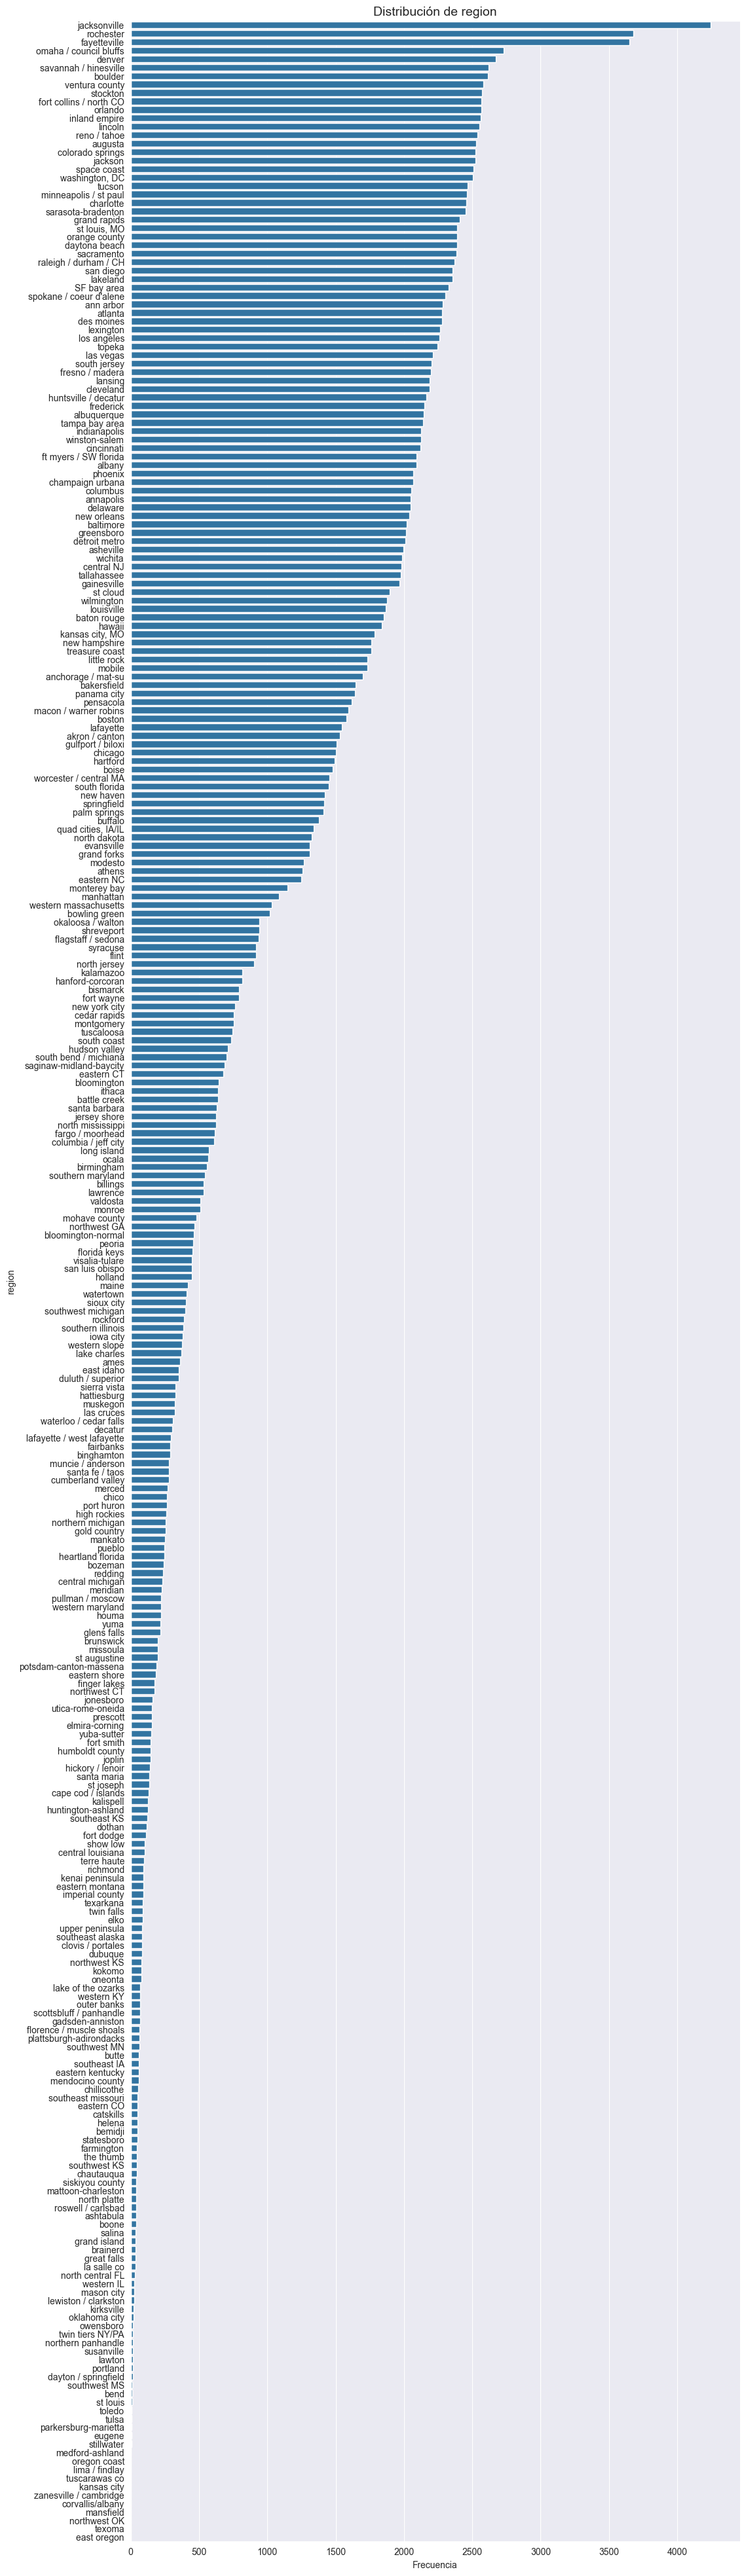

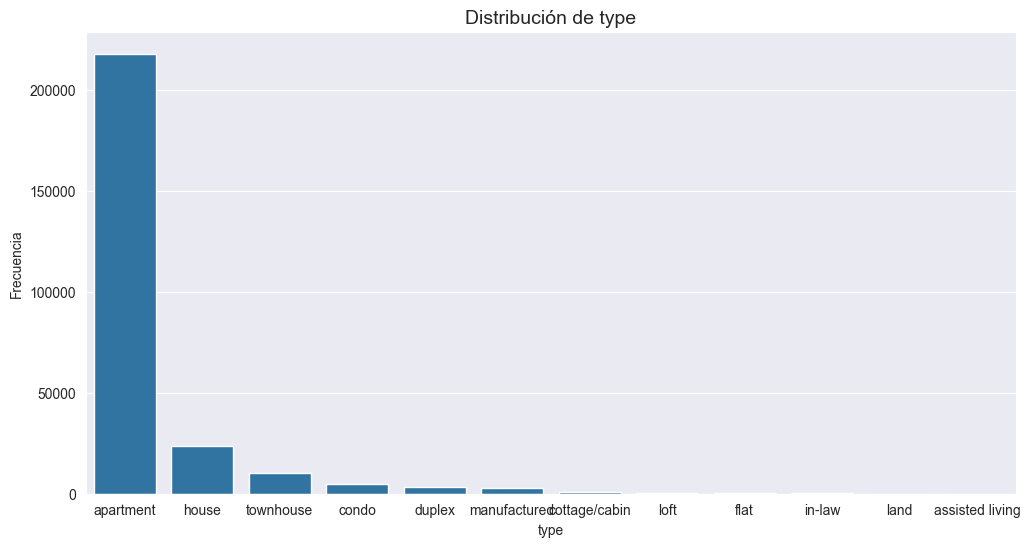

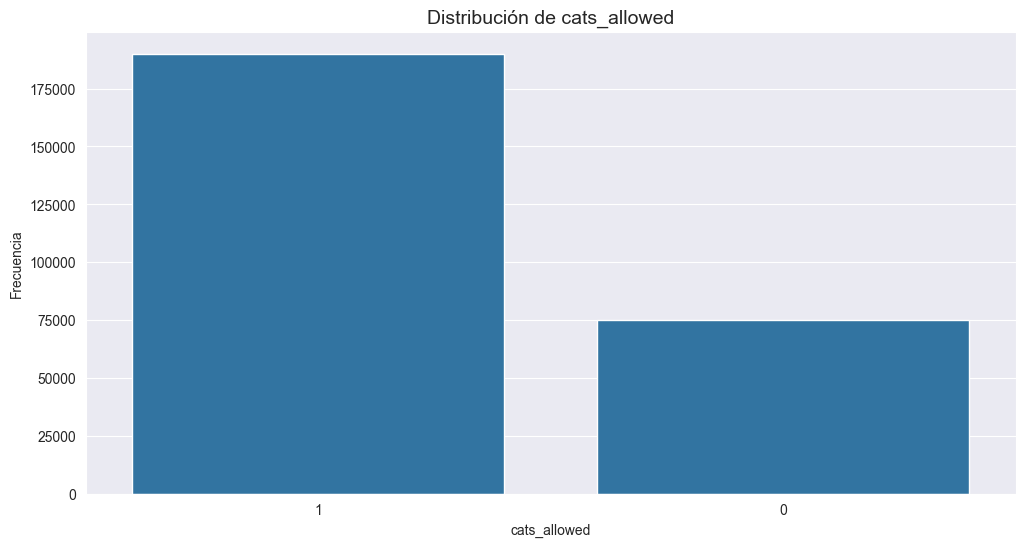

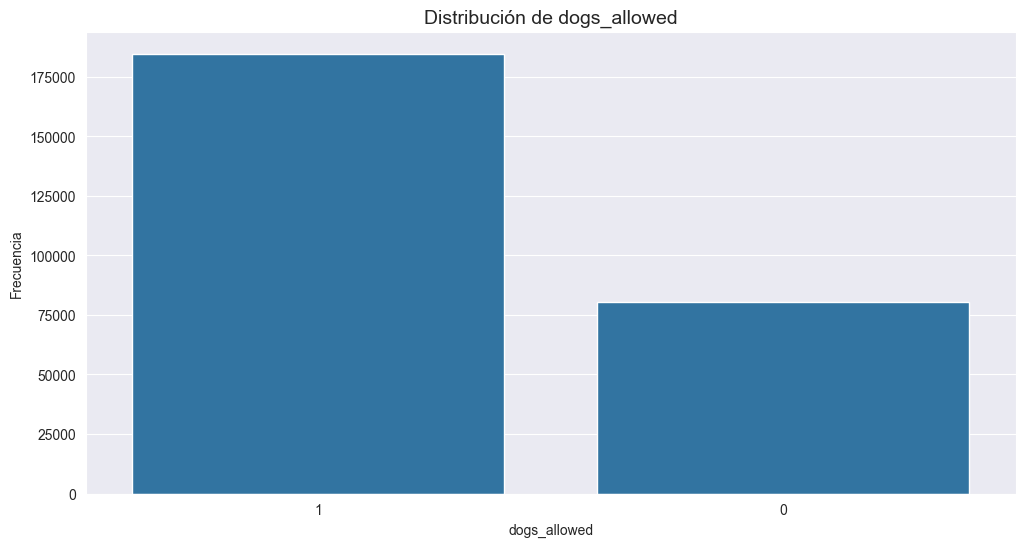

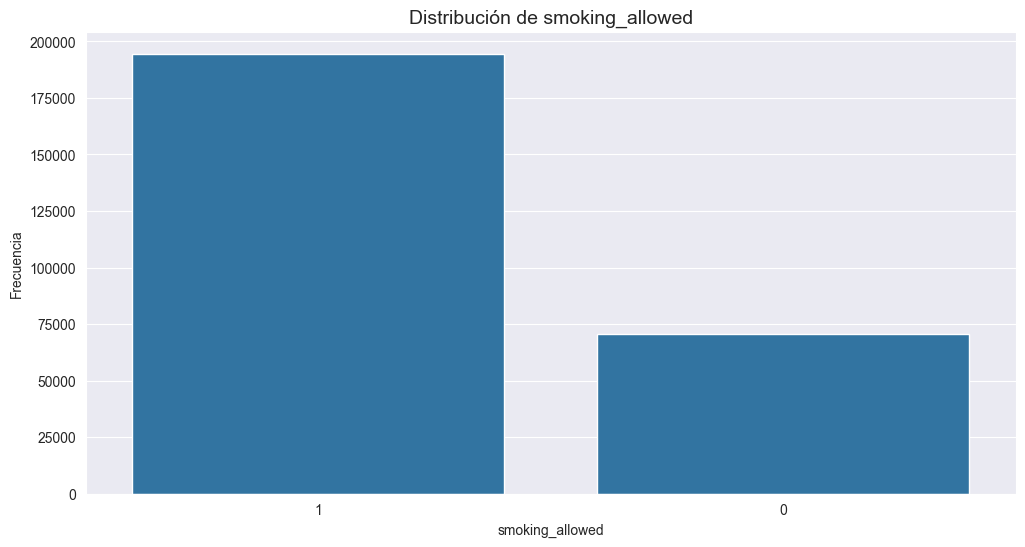

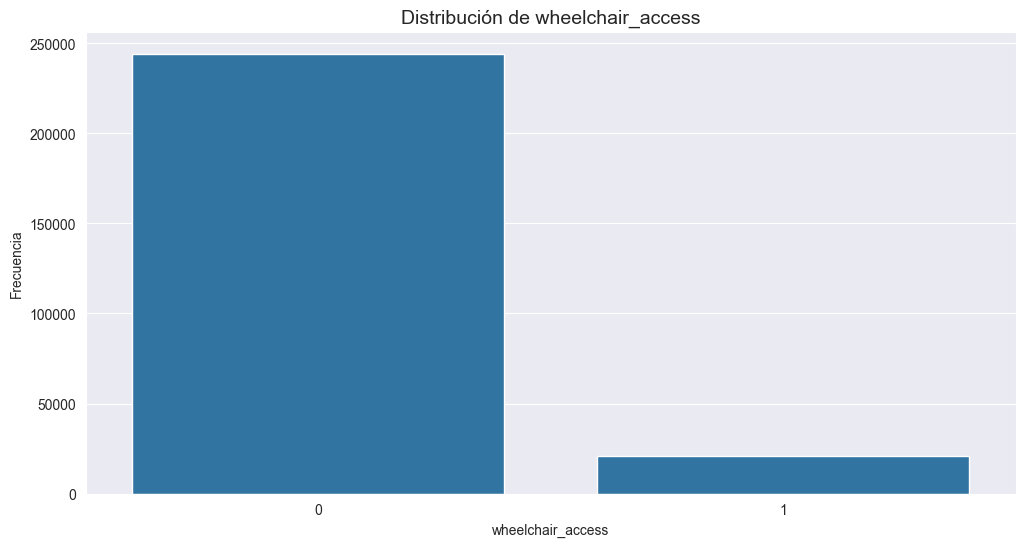

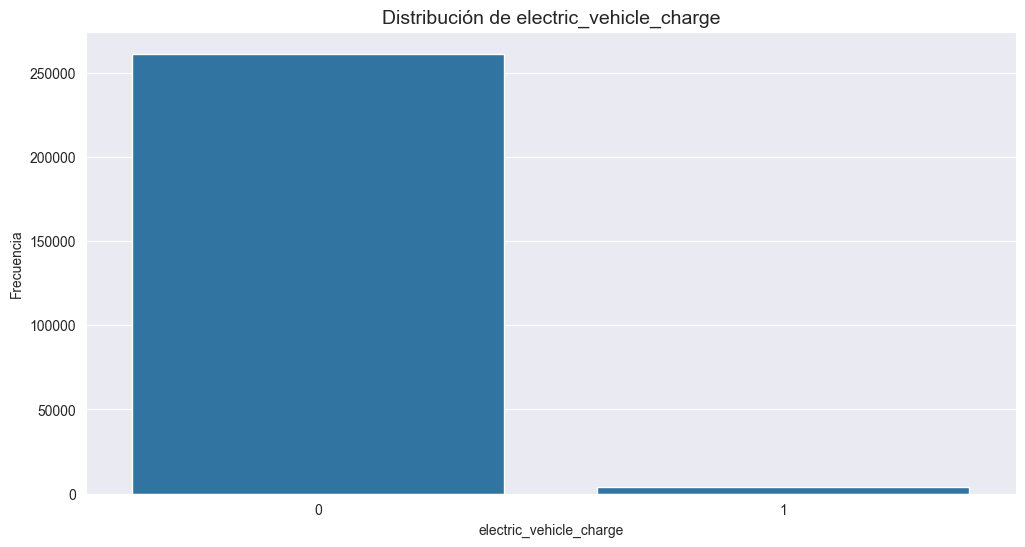

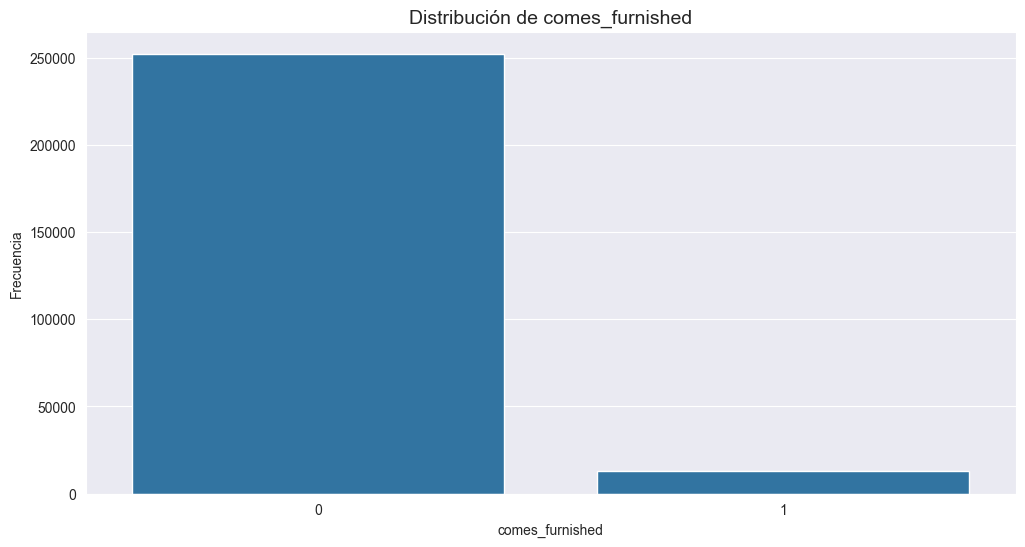

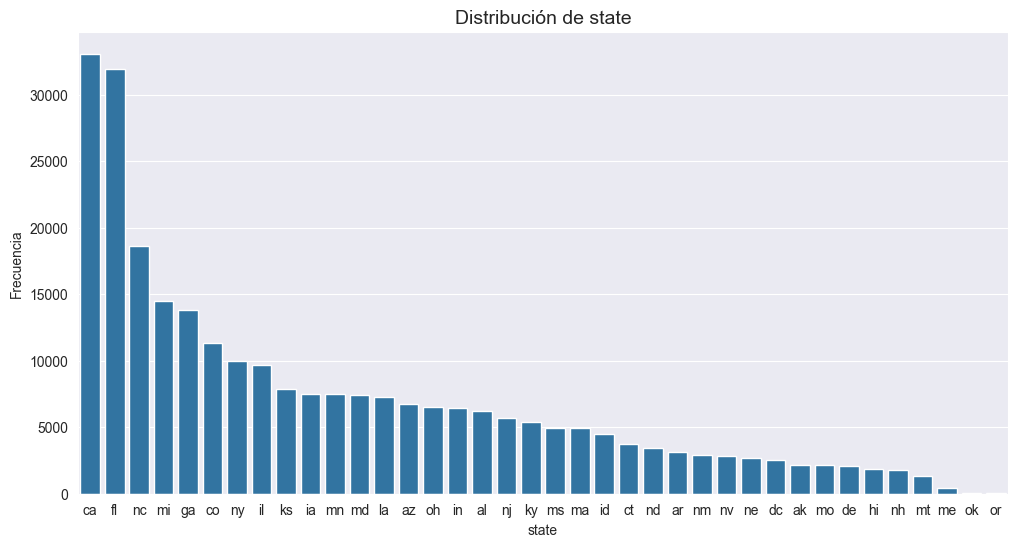

In [35]:
for var in vars_cat:
    order = data[var].value_counts().index
    if var == "region":
        plt.figure(figsize=(12, 50))
        sns.countplot(data=data, y=var, order=order)
        plt.title(f'Distribución de {var}', fontsize=14)
        plt.xlabel('Frecuencia')
        plt.ylabel(var)

    else:
        plt.figure(figsize=(12, 6))
        sns.countplot(data=data, x=var, order=order)
        plt.title(f'Distribución de {var}', fontsize=14)
        plt.xlabel(var)
        plt.ylabel('Frecuencia')
    plt.show()

### Paso 8.2: Análisis Univeriado de Variables Númericas

In [36]:
data[vars_disc].value_counts()

beds  baths
1     1.0      78139
2     2.0      60112
      1.0      44257
3     2.0      29446
2     1.5      12245
               ...  
7     5.5          1
      8.5          1
      7.5          1
8     8.0          1
1000  35.0         1
Name: count, Length: 94, dtype: int64

#### Paso 8.2.1: Análisis Univeriado de Variables Discretas

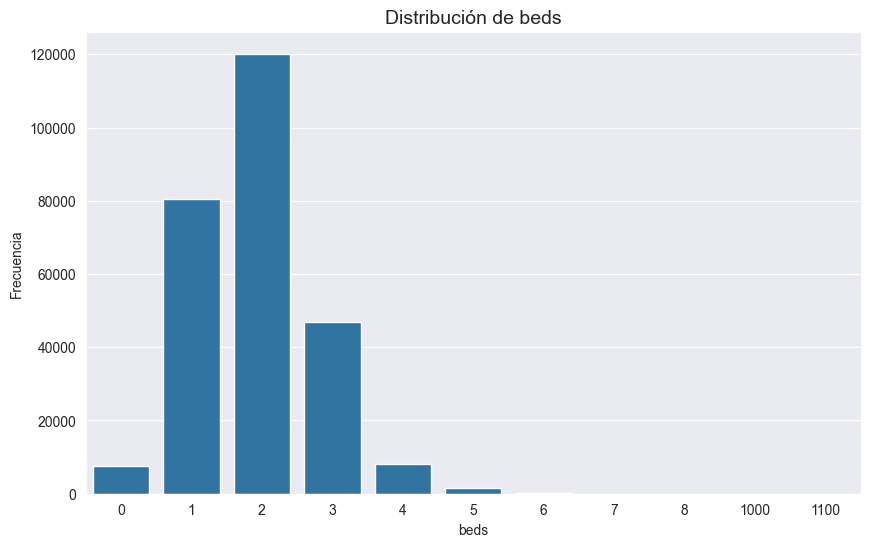

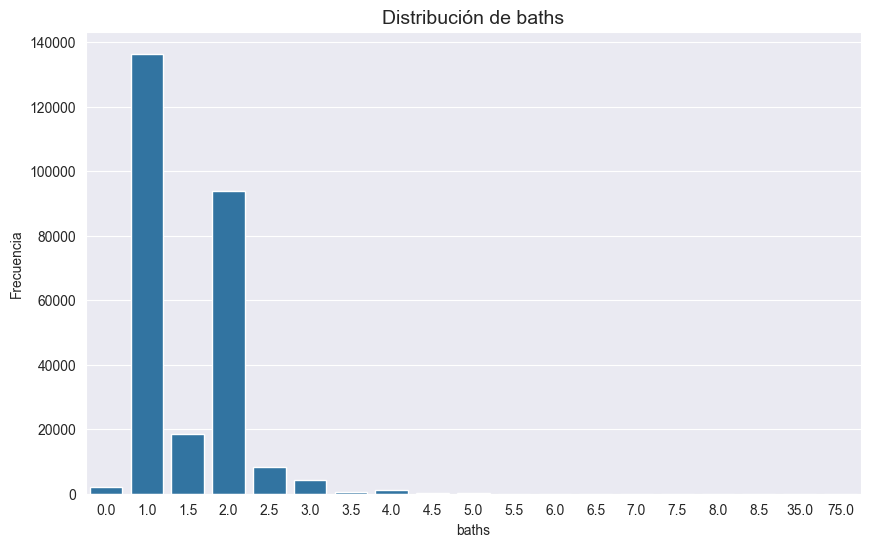

In [37]:
for var in vars_disc:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=data, x=var)
    plt.title(f'Distribución de {var}', fontsize=14)
    plt.xlabel(var)
    plt.ylabel('Frecuencia')
    plt.show()

#### Paso 8.2.2: Análisis Univeriado de Variables Continuas

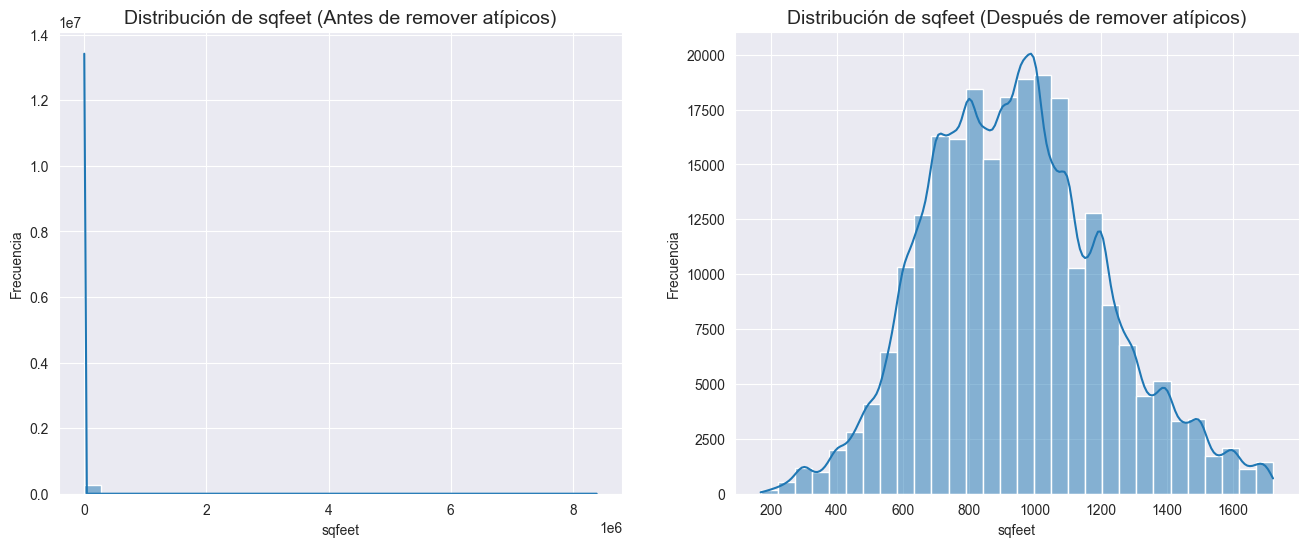

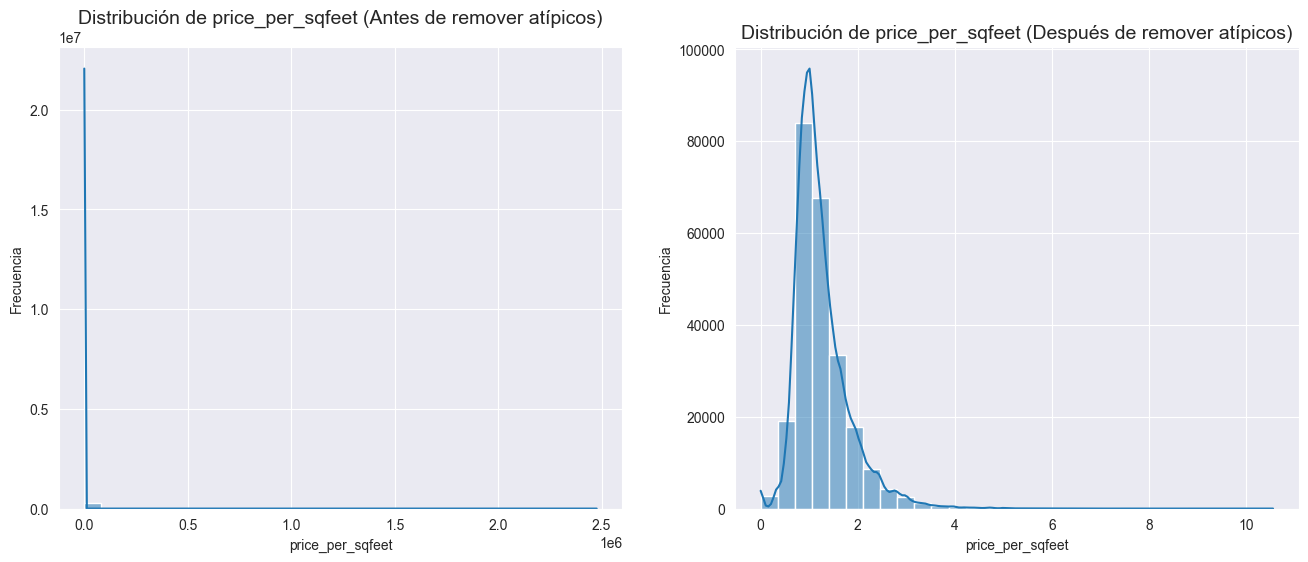

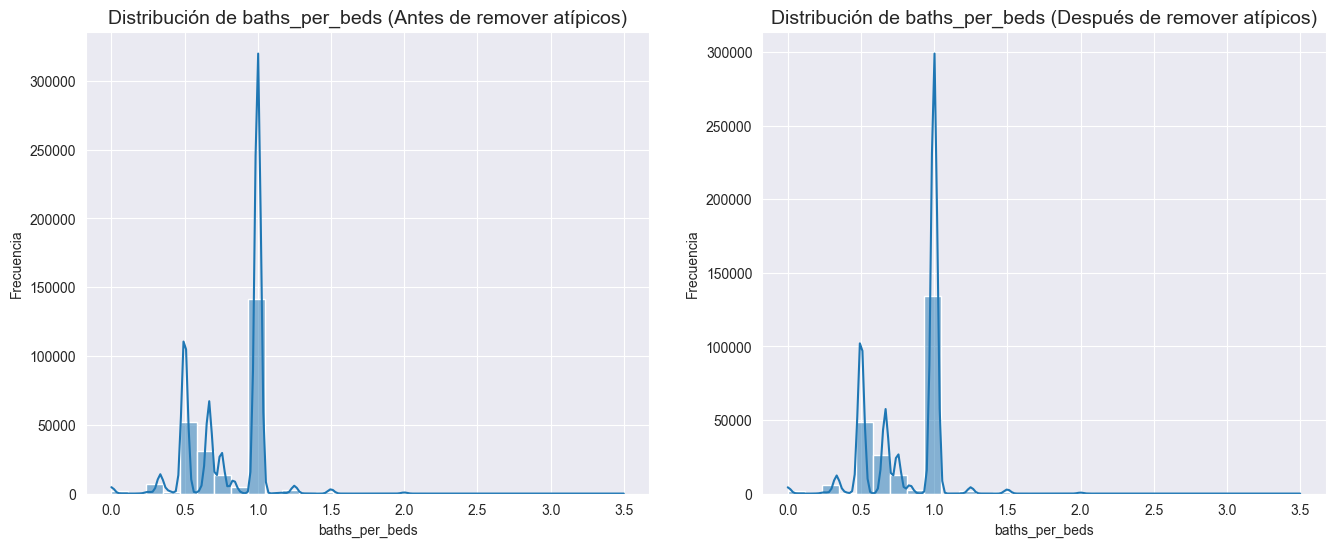

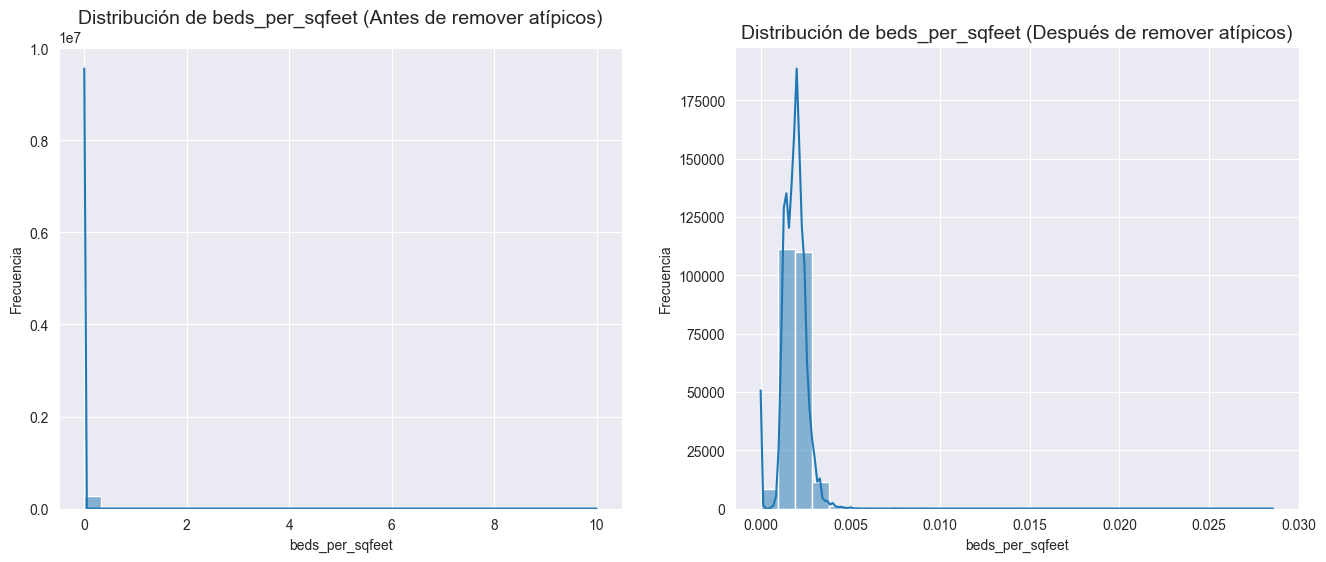

In [38]:
for var in vars_con:
    plt.figure(figsize=(16, 6))
    plt.subplot(1, 2, 1)
    sns.histplot(data[var], kde=True, bins=30)
    plt.title(f'Distribución de {var} (Antes de remover atípicos)', fontsize=14)
    plt.xlabel(var)
    plt.ylabel('Frecuencia')

    plt.subplot(1, 2, 2)
    sns.histplot(data_cleaned[var], kde=True, bins=30)
    plt.title(f'Distribución de {var} (Después de remover atípicos)', fontsize=14)
    plt.xlabel(var)
    plt.ylabel('Frecuencia')
    plt.show()

### Paso 8.3: Análisis Univeriado del Variable Objetivo

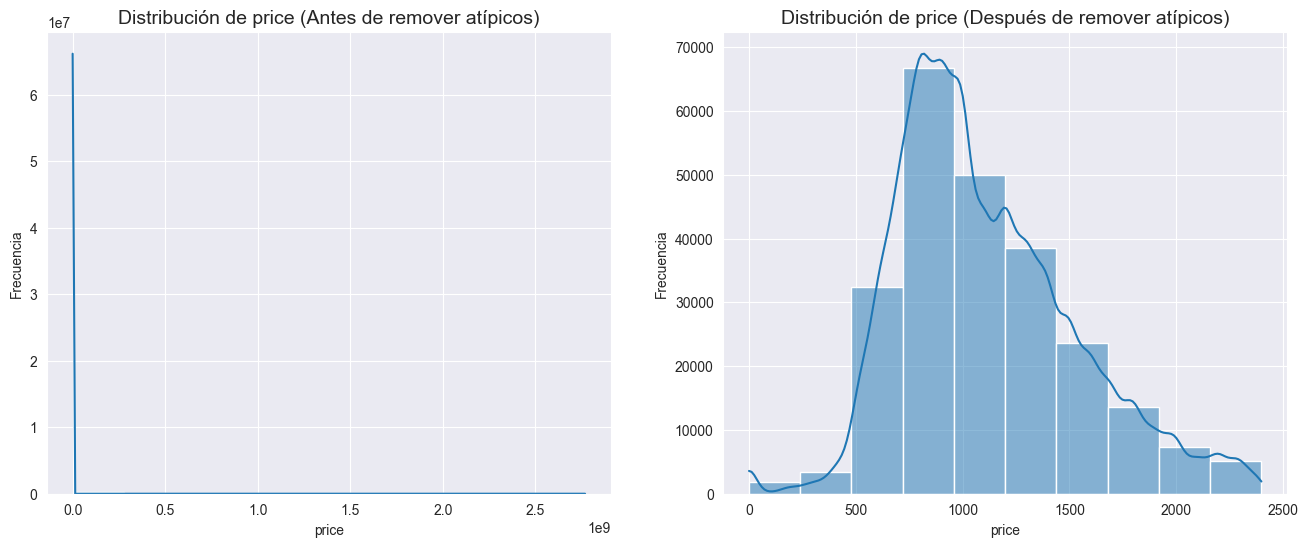

In [39]:
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
sns.histplot(data[targer_var], kde=True, bins=10)
plt.title(f'Distribución de {targer_var} (Antes de remover atípicos)', fontsize=14)
plt.xlabel(targer_var)
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(data_cleaned[targer_var], kde=True, bins=10)
plt.title(f'Distribución de {targer_var} (Después de remover atípicos)', fontsize=14)
plt.xlabel(targer_var)
plt.ylabel('Frecuencia')
plt.show()


## Paso 9: Análisis Bivariado

### Paso 9.1: Análisis Bivariado: Relación con el Precio

In [40]:
data.head()

,region,price,type,sqfeet,beds,baths,cats_allowed,dogs_allowed,smoking_allowed,wheelchair_access,electric_vehicle_charge,comes_furnished,state,price_per_sqfeet,baths_per_beds,beds_per_sqfeet
0,birmingham,1195,apartment,1908,3,2.0,1,1,1,0,0,0,al,0.626310,0.666667,0.001572
1,birmingham,1120,apartment,1319,3,2.0,1,1,1,0,0,0,al,0.849128,0.666667,0.002274
2,birmingham,825,apartment,1133,1,1.5,1,1,1,0,0,0,al,0.728155,1.500000,0.000883
3,birmingham,800,apartment,927,1,1.0,1,1,1,0,0,0,al,0.862999,1.000000,0.001079
4,birmingham,785,apartment,1047,2,1.0,1,1,1,0,0,0,al,0.749761,0.500000,0.001910


In [41]:
vars_nums

['sqfeet',
 'beds',
 'baths',
 'price_per_sqfeet',
 'baths_per_beds',
 'beds_per_sqfeet']

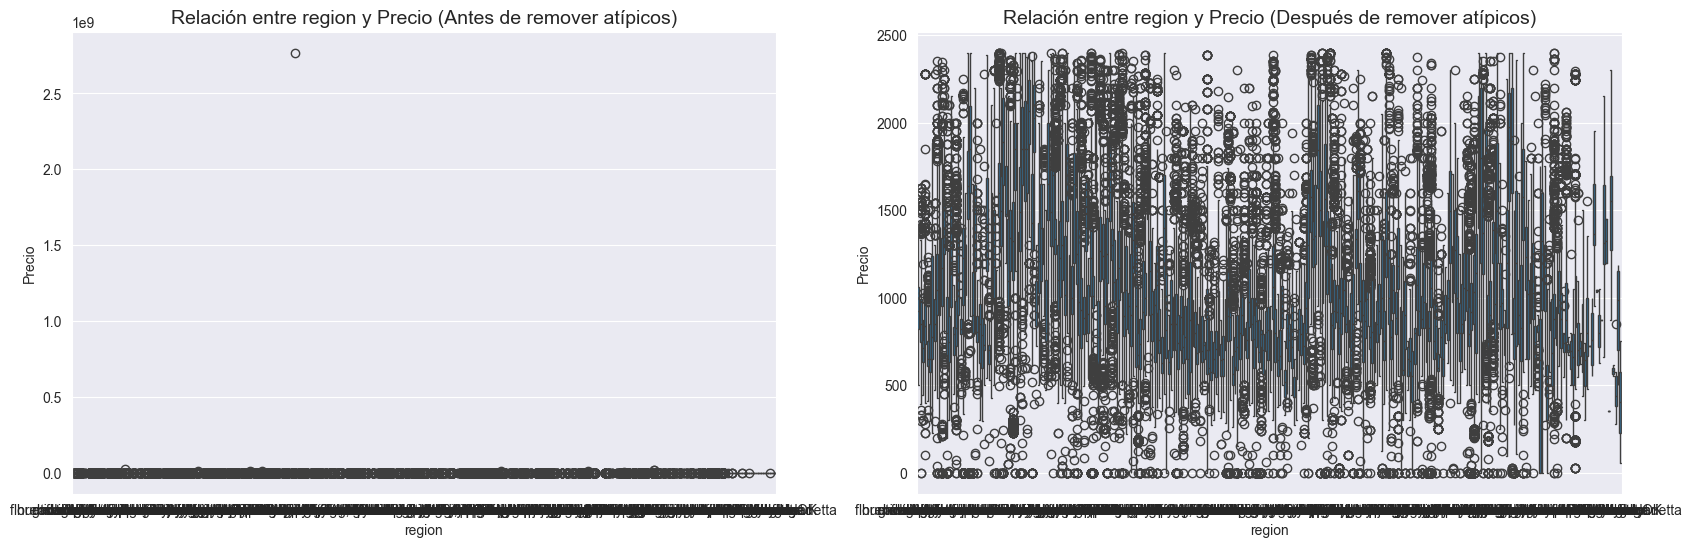

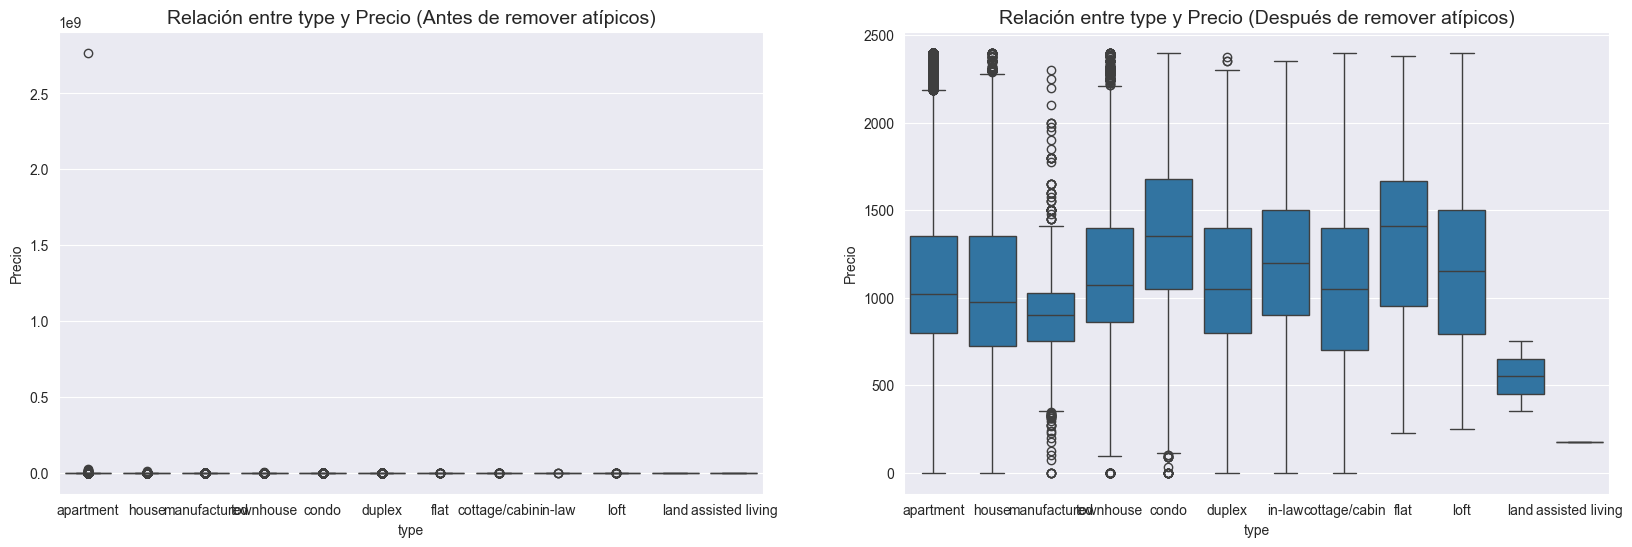

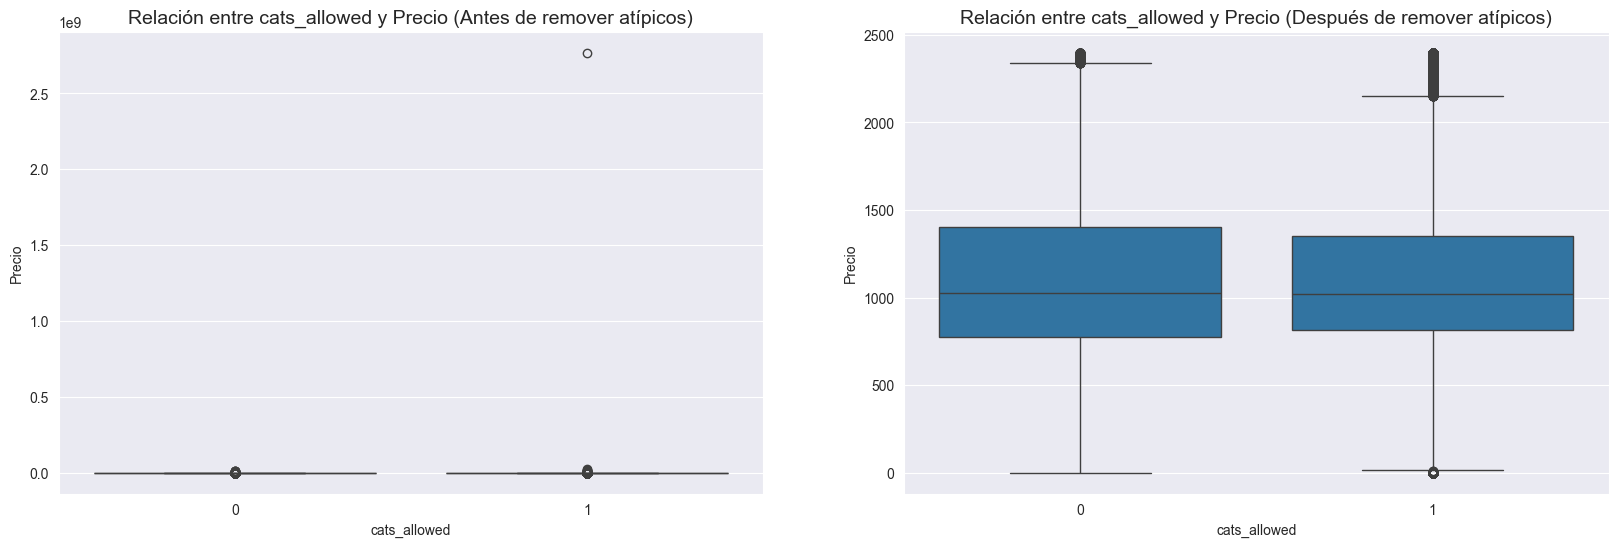

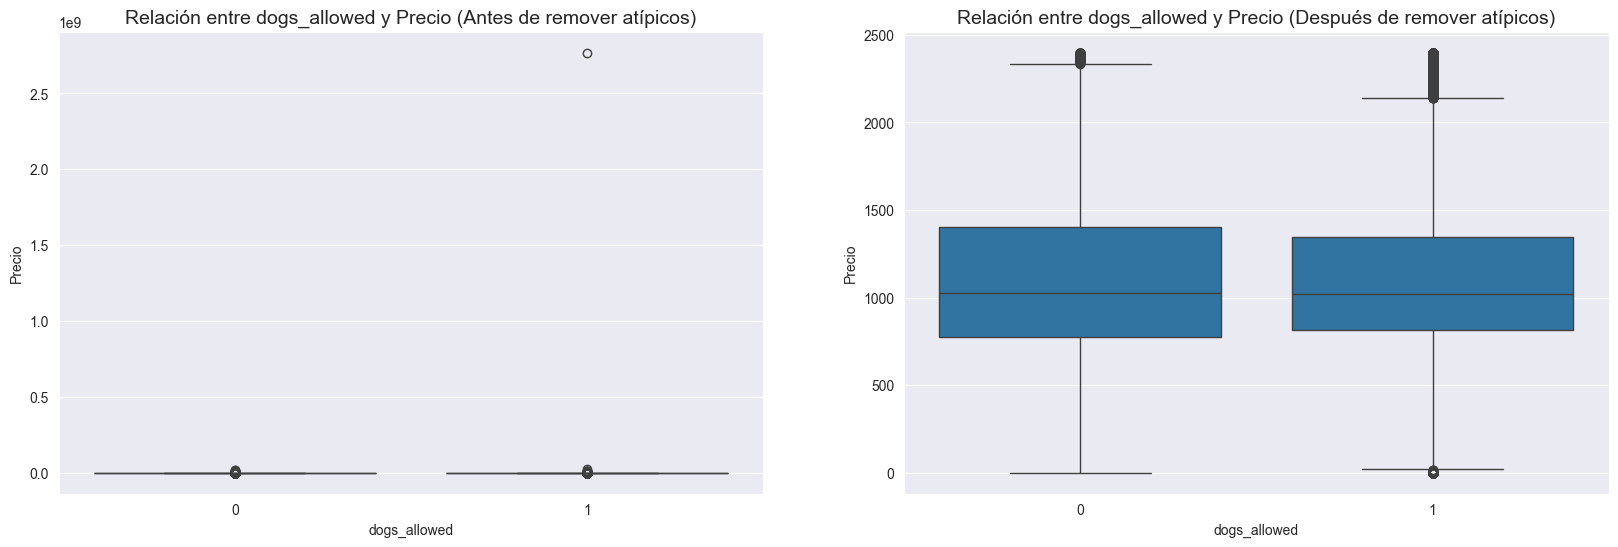

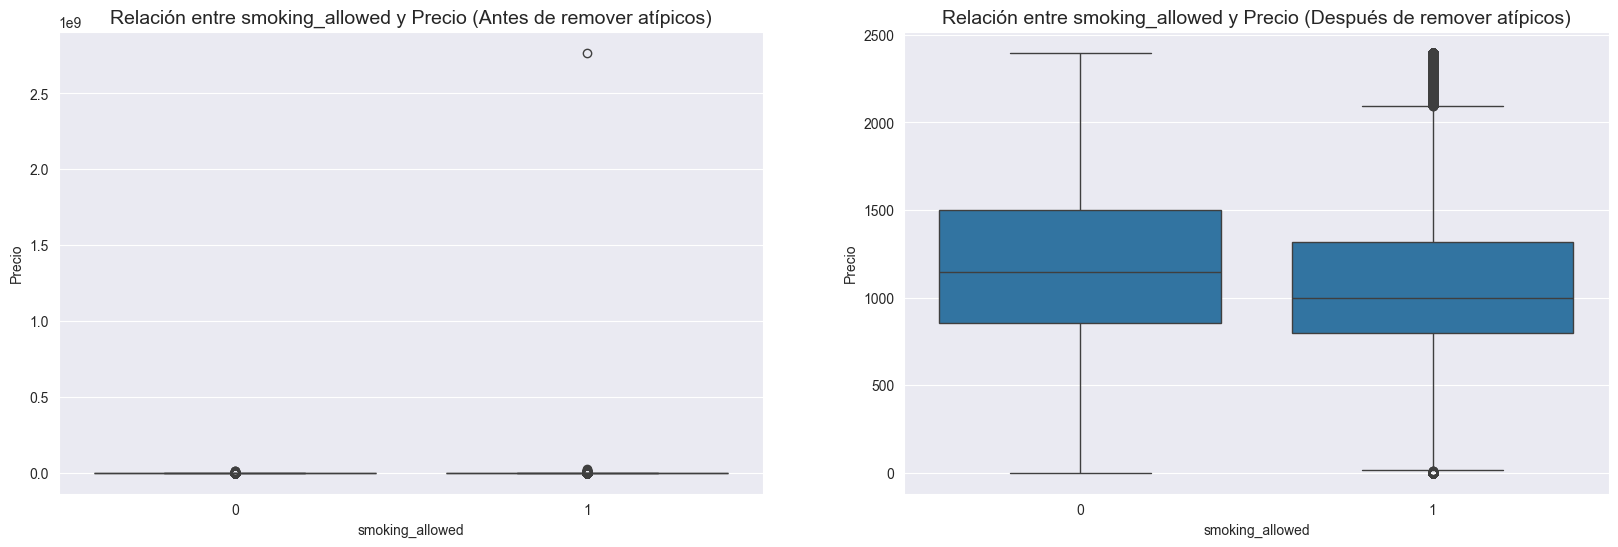

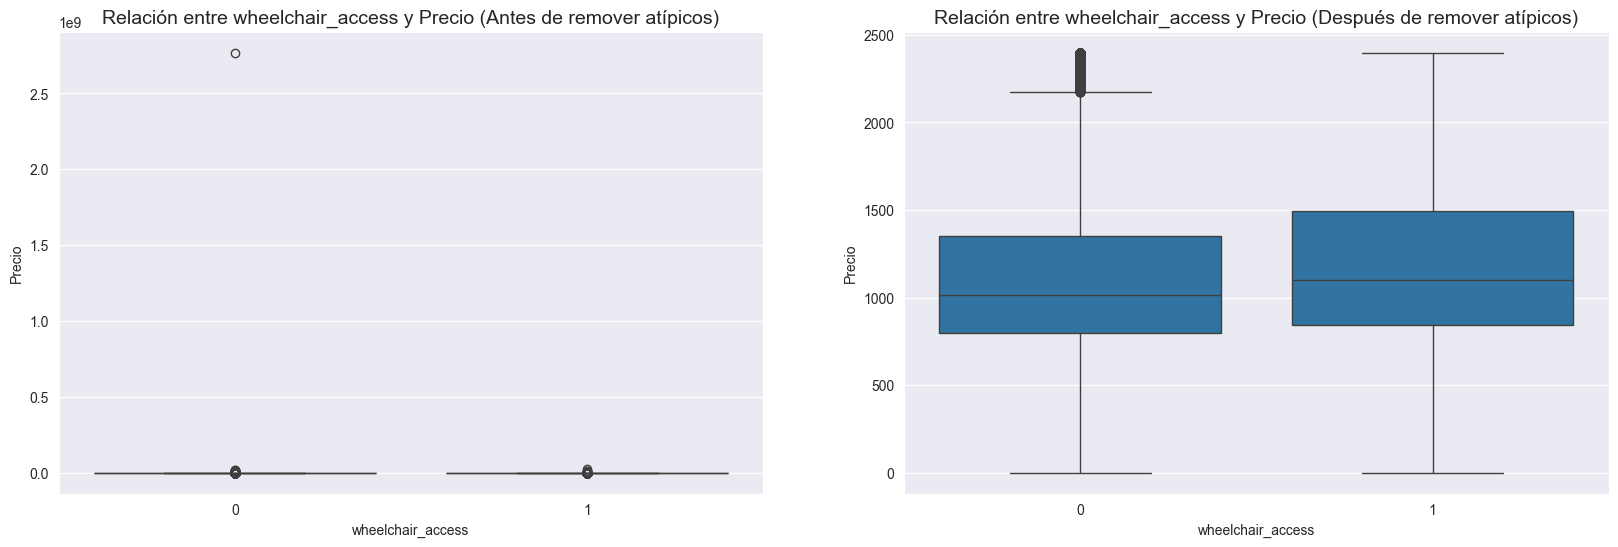

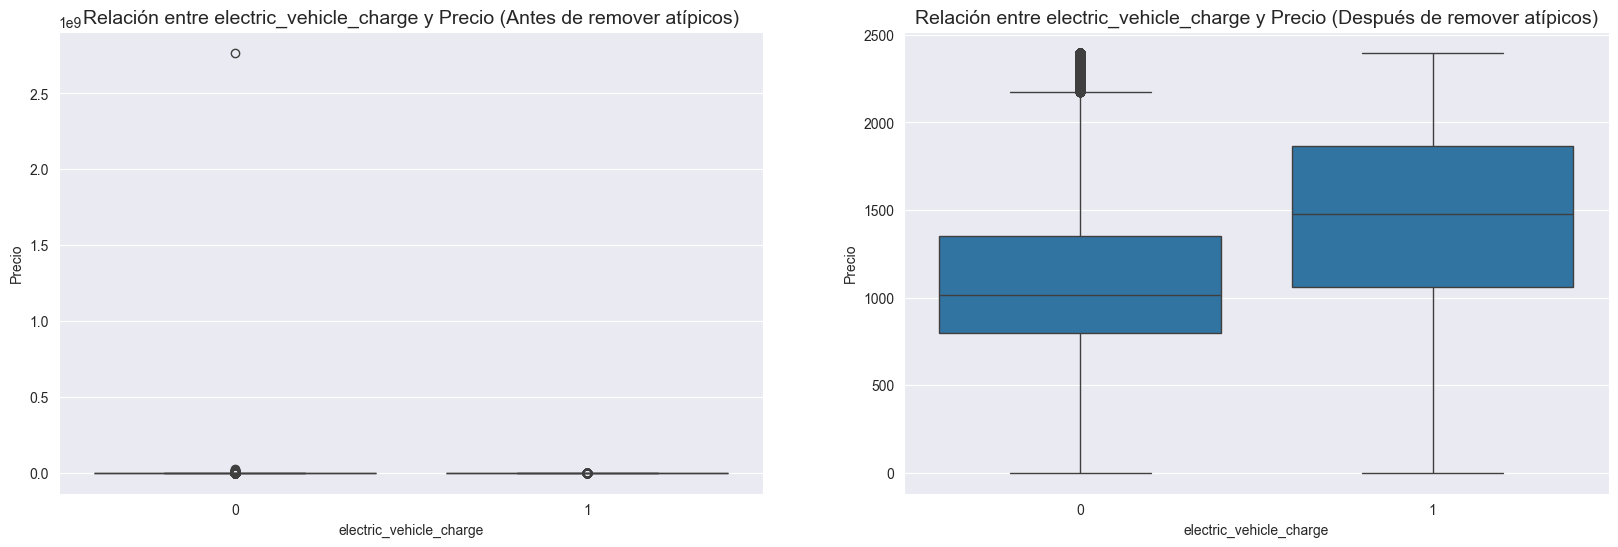

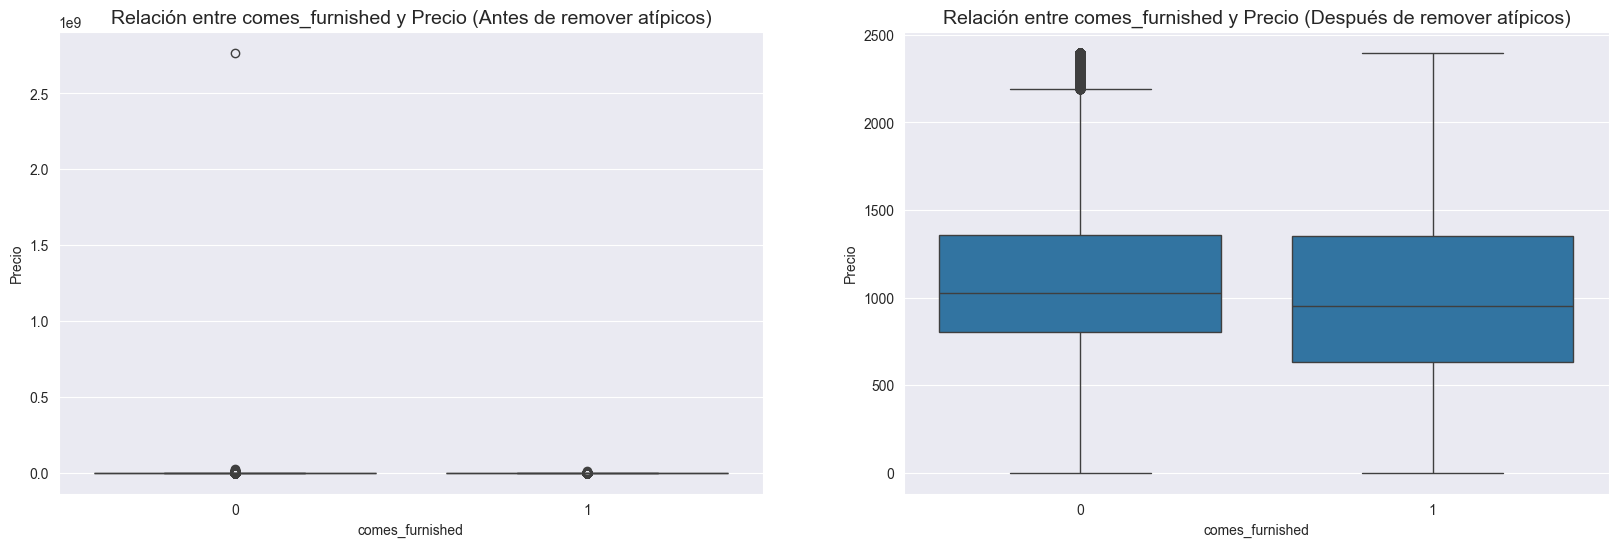

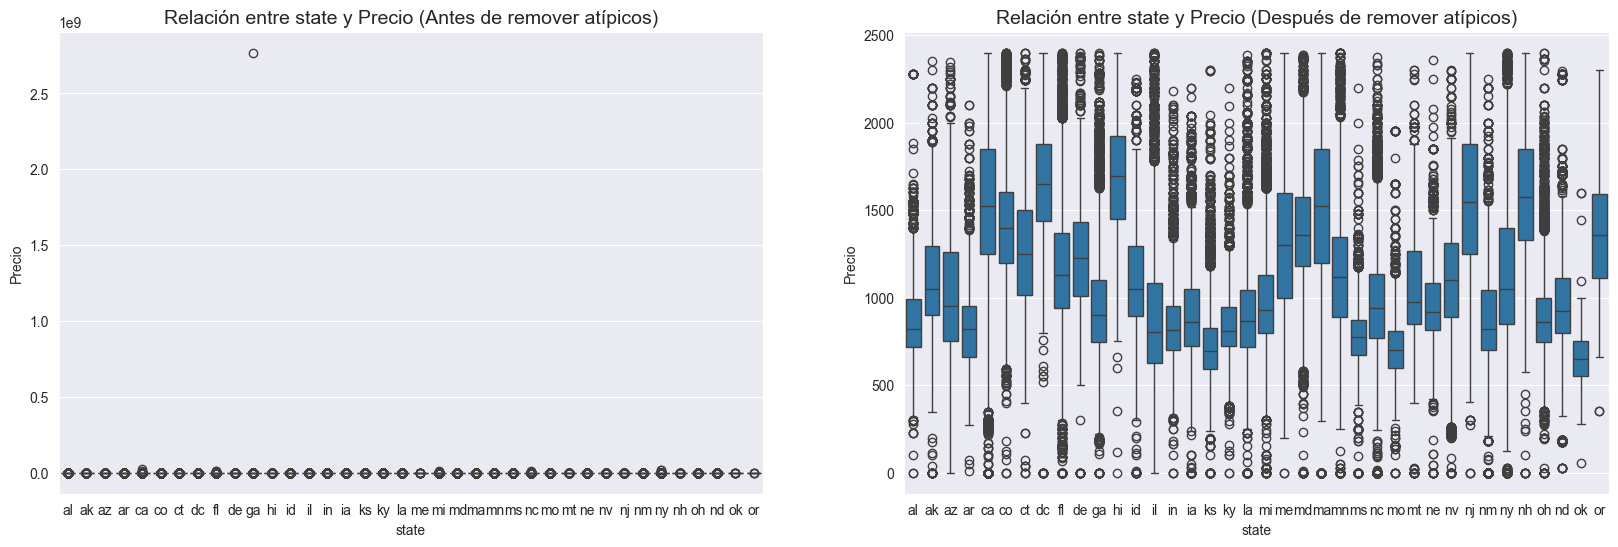

In [42]:
for col in vars_cat:
    plt.figure(figsize=(20, 6))
    plt.subplot(1, 2, 1)
    sns.boxplot(data=data, x=col, y=targer_var)
    plt.title(f'Relación entre {col} y Precio (Antes de remover atípicos)', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Precio')

    plt.subplot(1, 2, 2)
    sns.boxplot(data=data_cleaned, x=col, y=targer_var)
    plt.title(f'Relación entre {col} y Precio (Después de remover atípicos)', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Precio')
    plt.show()

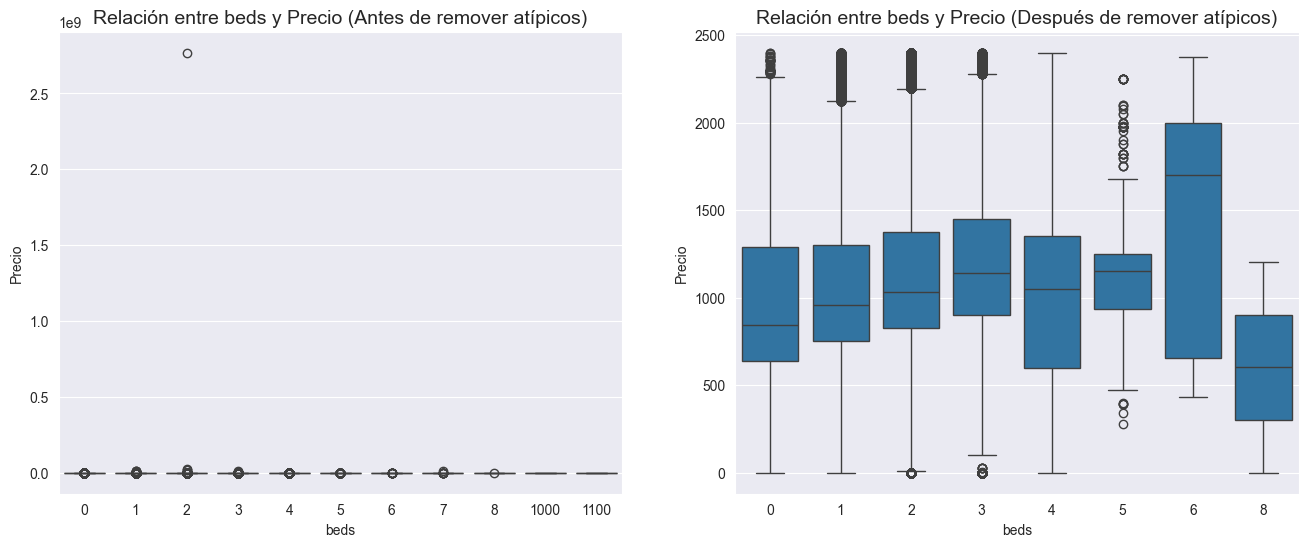

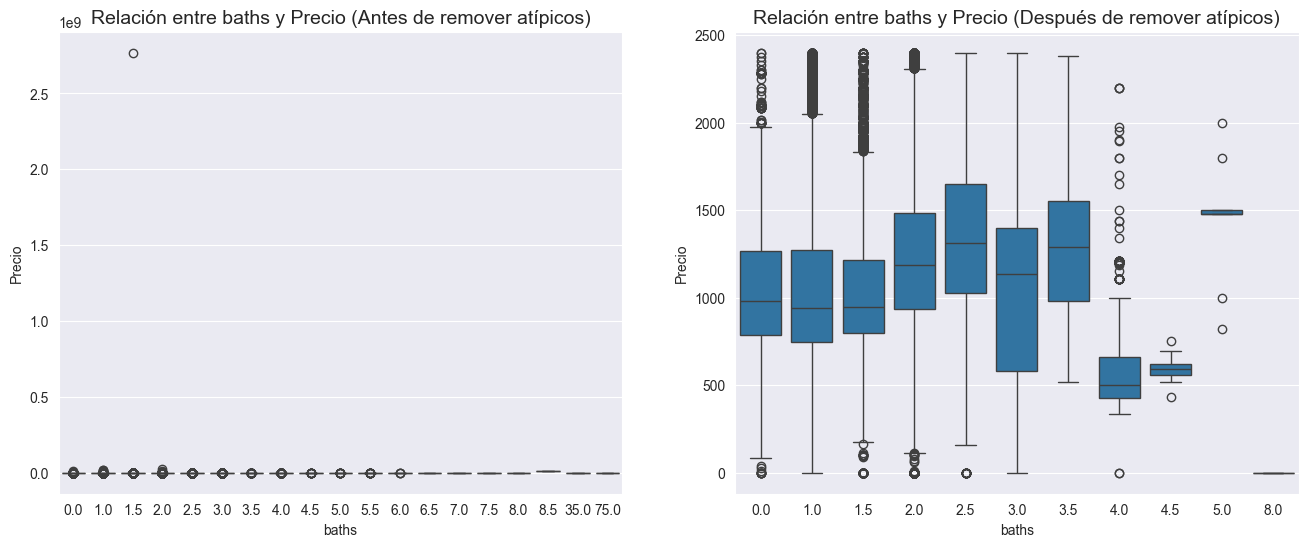

In [43]:
for col in vars_disc:
    plt.figure(figsize=(16, 6))
    plt.subplot(1, 2, 1)
    sns.boxplot(data=data, x=col, y=targer_var)
    plt.title(f'Relación entre {col} y Precio (Antes de remover atípicos)', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Precio')

    plt.subplot(1, 2, 2)
    sns.boxplot(data=data_cleaned, x=col, y=targer_var)
    plt.title(f'Relación entre {col} y Precio (Después de remover atípicos)', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Precio')
    plt.show()

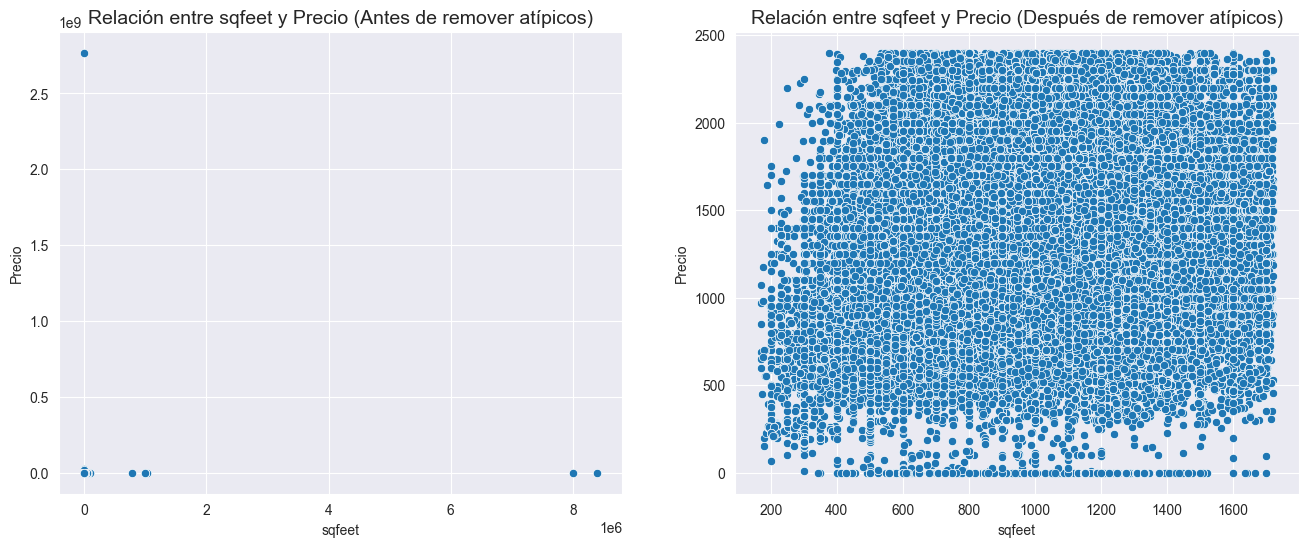

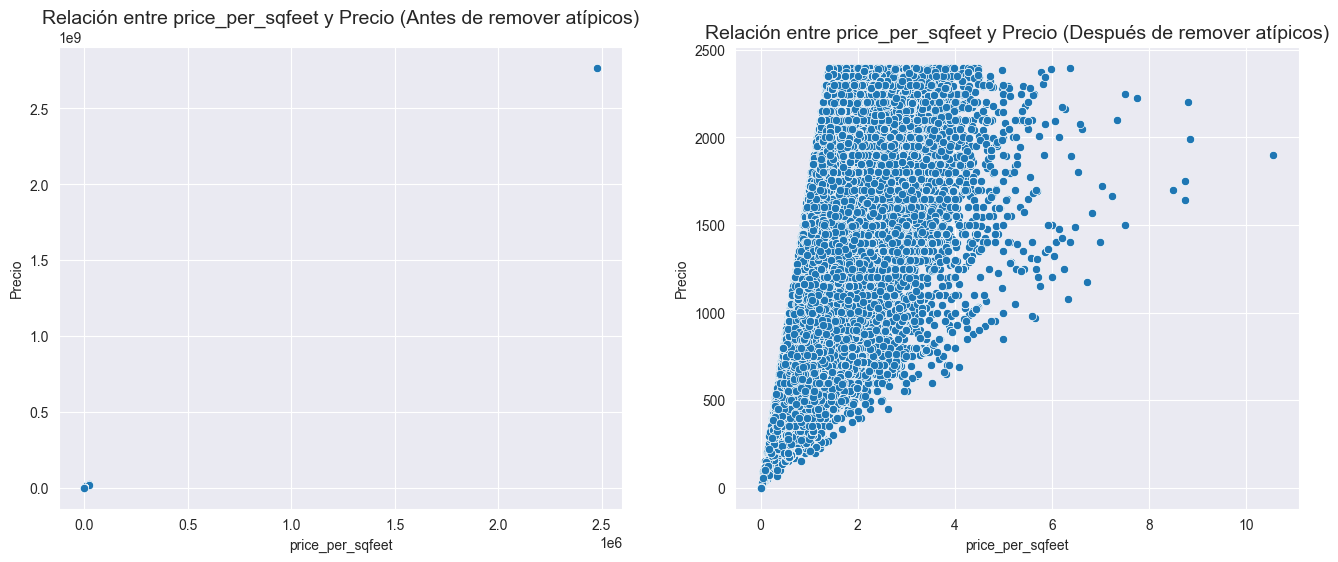

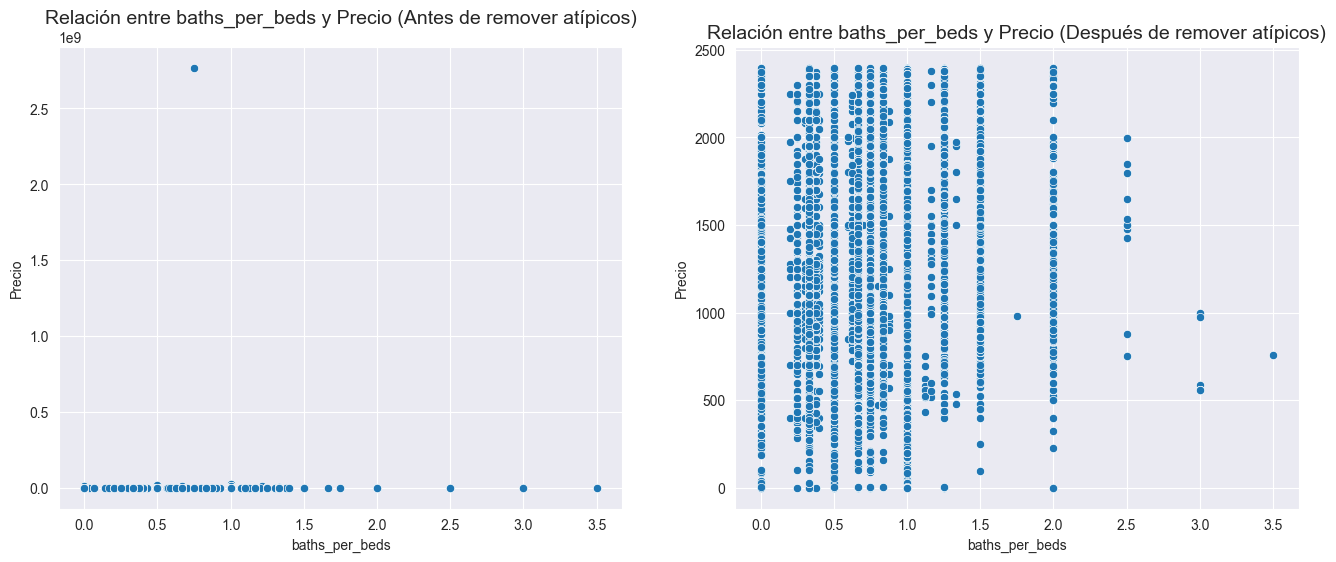

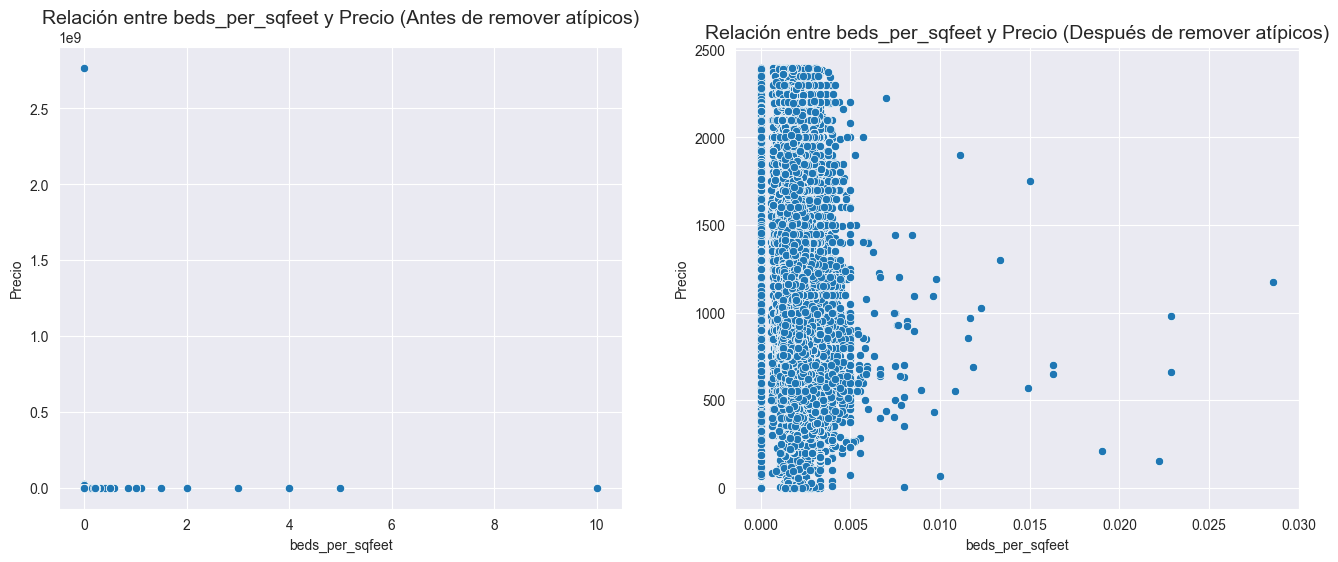

In [44]:
for col in vars_con:
    plt.figure(figsize=(16, 6))
    plt.subplot(1, 2, 1)
    sns.scatterplot(data=data, x=col, y=targer_var)
    plt.title(f'Relación entre {col} y Precio (Antes de remover atípicos)', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Precio')

    plt.subplot(1, 2, 2)
    sns.scatterplot(data=data_cleaned, x=col, y=targer_var)
    plt.title(f'Relación entre {col} y Precio (Después de remover atípicos)', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Precio')
    plt.show()


## Paso 10: Análisis multivariado

### Paso 10.1: Análisis de Correlación

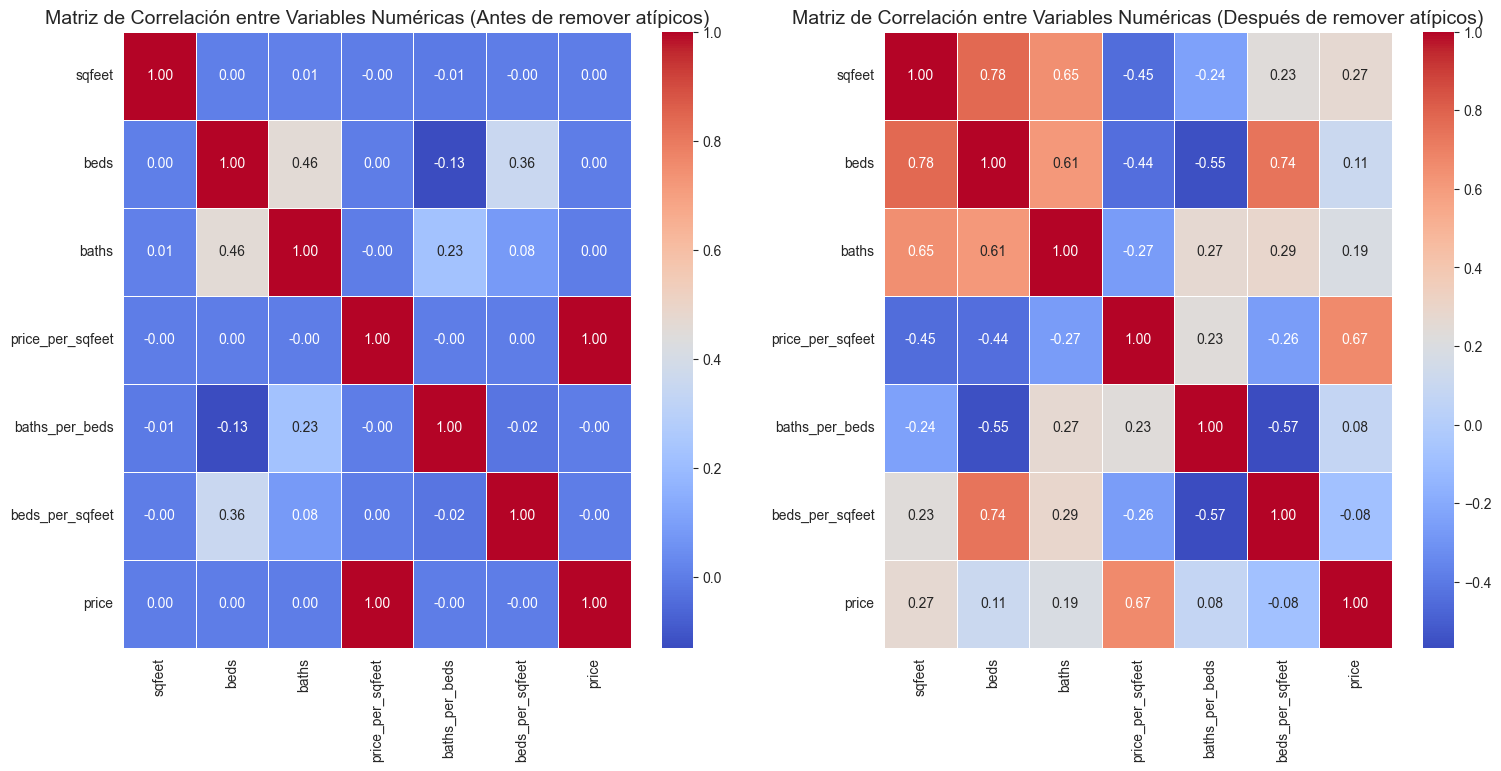

In [45]:
correlation_matrix = data[vars_nums + [targer_var]].corr()
plt.figure(figsize=(18, 8))
plt.subplot(1, 2, 1)
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación entre Variables Numéricas (Antes de remover atípicos)", fontsize=14)

correlation_matrix_cleaned = data_cleaned[vars_nums + [targer_var]].corr()
plt.subplot(1, 2, 2)
sns.heatmap(correlation_matrix_cleaned, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación entre Variables Numéricas (Después de remover atípicos)", fontsize=14)
plt.show()

## Paso 11: Pruebas de Hipotesis

## Paso 12: Preparación de los Datos

In [46]:
data.head()

,region,price,type,sqfeet,beds,baths,cats_allowed,dogs_allowed,smoking_allowed,wheelchair_access,electric_vehicle_charge,comes_furnished,state,price_per_sqfeet,baths_per_beds,beds_per_sqfeet
0,birmingham,1195,apartment,1908,3,2.0,1,1,1,0,0,0,al,0.626310,0.666667,0.001572
1,birmingham,1120,apartment,1319,3,2.0,1,1,1,0,0,0,al,0.849128,0.666667,0.002274
2,birmingham,825,apartment,1133,1,1.5,1,1,1,0,0,0,al,0.728155,1.500000,0.000883
3,birmingham,800,apartment,927,1,1.0,1,1,1,0,0,0,al,0.862999,1.000000,0.001079
4,birmingham,785,apartment,1047,2,1.0,1,1,1,0,0,0,al,0.749761,0.500000,0.001910


In [47]:
# --------------------------------------
# 6. Codificación de Variables Categóricas
# --------------------------------------
categorical_columns = ['type', 'state', 'region']
df_encoded = pd.get_dummies(data_cleaned, columns=categorical_columns, drop_first=True)

# Mostrar las primeras filas codificadas
print(df_encoded.head())

   price  sqfeet  beds  baths  cats_allowed  dogs_allowed  smoking_allowed  \
1   1120    1319     3    2.0             1             1                1   
2    825    1133     1    1.5             1             1                1   
3    800     927     1    1.0             1             1                1   
4    785    1047     2    1.0             1             1                1   
5    900    1298     2    2.0             1             1                1   

   wheelchair_access  electric_vehicle_charge  comes_furnished  ...  \
1                  0                        0                0  ...   
2                  0                        0                0  ...   
3                  0                        0                0  ...   
4                  0                        0                0  ...   
5                  0                        0                0  ...   

   region_western maryland  region_western massachusetts  \
1                    False                  

In [48]:
df_encoded.dtypes

price                              int64
sqfeet                             int64
beds                               int64
baths                            float64
cats_allowed                       int64
                                  ...   
region_winston-salem                bool
region_worcester / central MA       bool
region_yuba-sutter                  bool
region_yuma                         bool
region_zanesville / cambridge       bool
Length: 358, dtype: object

In [61]:
# Variables objetivo y predictoras para la base original
X_original = data[['beds', 'baths', 'sqfeet']]
y_original = data['price']

# Variables para la base tratada (sin atípicos, codificada y con nuevas características)
X_processed = df_encoded[['beds', 'baths', 'sqfeet']]
y_processed = df_encoded['price']

# Variables para la base tratada (sin atípicos, codificada y con nuevas características)
X_processed2 = df_encoded[['beds', 'baths', 'sqfeet', 'smoking_allowed', "wheelchair_access", "price_per_sqfeet", "baths_per_beds",  "beds_per_sqfeet"]]
y_processed2 = df_encoded['price']

In [63]:
# División train-test
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(X_original, y_original, test_size=0.2, random_state=42)
X_train_proc, X_test_proc, y_train_proc, y_test_proc = train_test_split(X_processed, y_processed, test_size=0.2, random_state=42)
X_train_proc2, X_test_proc2, y_train_proc2, y_test_proc2 = train_test_split(X_processed2, y_processed2, test_size=0.2, random_state=42)

In [51]:
# Función para entrenar, evaluar y graficar modelos
def train_and_evaluate_model(model, X_train, X_test, y_train, y_test, title):
    # Entrenamiento
    model.fit(X_train, y_train)

    # Predicciones
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Cálculo de métricas
    metrics = {
        "MAE_Train": mean_absolute_error(y_train, y_pred_train),
        "RMSE_Train": np.sqrt(mean_squared_error(y_train, y_pred_train)),
        "R2_Train": r2_score(y_train, y_pred_train),
        "MAE_Test": mean_absolute_error(y_test, y_pred_test),
        "RMSE_Test": np.sqrt(mean_squared_error(y_test, y_pred_test)),
        "R2_Test": r2_score(y_test, y_pred_test)
    }

    # Gráfico de predicciones vs valores reales
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=y_test, y=y_pred_test, alpha=0.7)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red')
    plt.xlabel("Precio Real")
    plt.ylabel("Precio Predicho")
    plt.title(f"{title} - Predicción vs Real")
    plt.show()

    return metrics

In [52]:
# --------------------------------------------
# 2. Modelos y Evaluación
# --------------------------------------------

models = {
    "Regresión Lineal Múltiple": LinearRegression(),
    "Lasso (alpha=0.1)": Lasso(alpha=0.1),
    "Ridge (alpha=1.0)": Ridge(alpha=1.0)
}

results = []


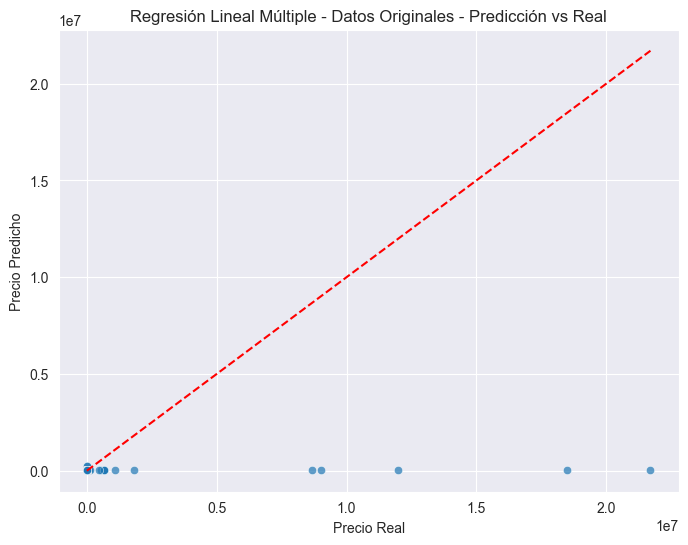

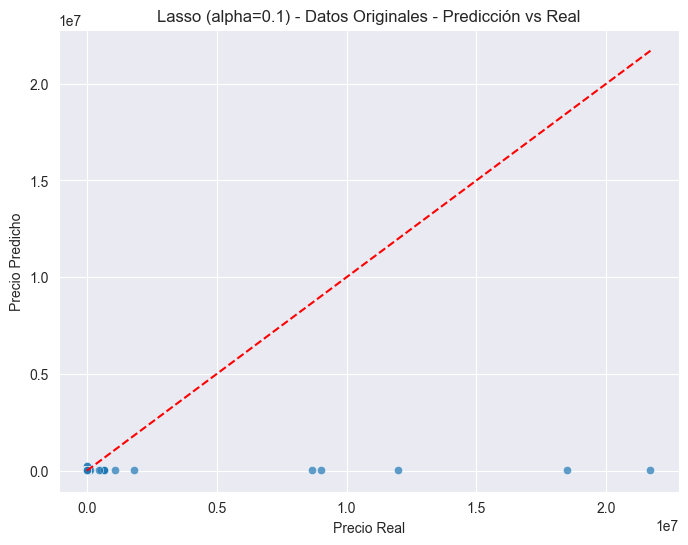

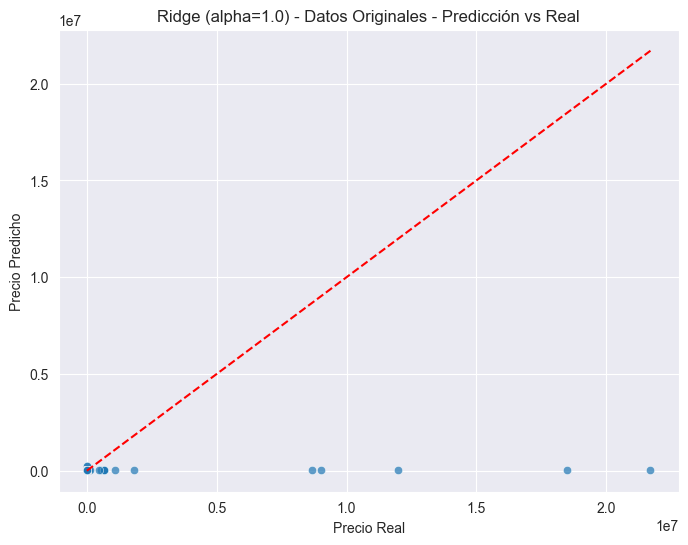

In [53]:
# Entrenamiento y evaluación con la base original
for name, model in models.items():
    metrics = train_and_evaluate_model(model, X_train_orig, X_test_orig, y_train_orig, y_test_orig, f"{name} - Datos Originales")
    results.append({"Modelo": name + " - Original", **metrics})


In [54]:
df_encoded.dtypes

price                              int64
sqfeet                             int64
beds                               int64
baths                            float64
cats_allowed                       int64
                                  ...   
region_winston-salem                bool
region_worcester / central MA       bool
region_yuba-sutter                  bool
region_yuma                         bool
region_zanesville / cambridge       bool
Length: 358, dtype: object

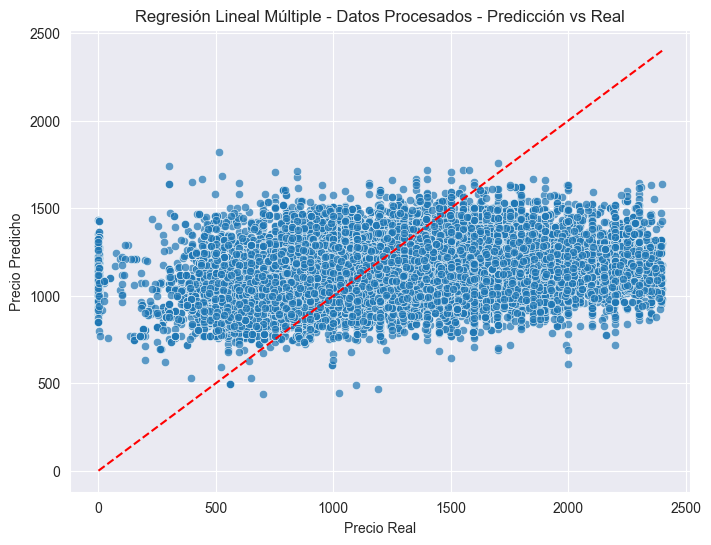

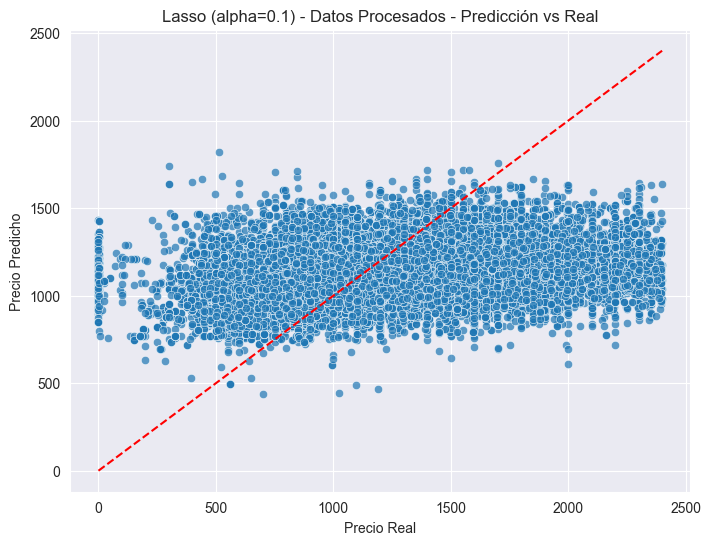

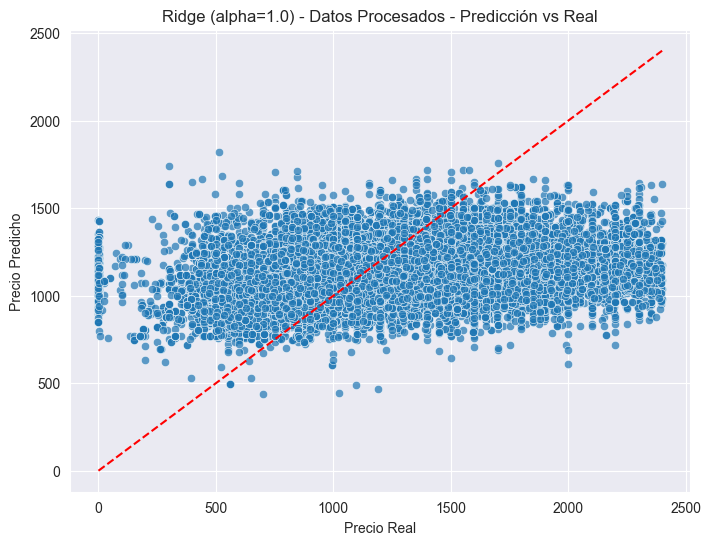

In [64]:
# Entrenamiento y evaluación con la base tratada
for name, model in models.items():
    metrics = train_and_evaluate_model(model, X_train_proc, X_test_proc, y_train_proc, y_test_proc, f"{name} - Datos Procesados")
    results.append({"Modelo": name + " - Procesado", **metrics})

In [65]:
# Entrenamiento y evaluación con la base tratada
for name, model in models.items():
    metrics = train_and_evaluate_model(model, X_train_proc2, X_test_proc2, y_train_proc2, y_test_proc2, f"{name} - Datos Procesados")
    results.append({"Modelo": name + " - Procesado", **metrics})

ValueError: Input X contains infinity or a value too large for dtype('float64').